# Реализация Deep Q-Network (DQN)


### Подготовка среды


In [ ]:
import sys, os
if 'google.colab' in sys.modules and not os.path.exists('.setup_complete'):
    os.makedirs('dqn', exist_ok=True)
    !wget -q https://raw.githubusercontent.com/yandexdataschool/Practical_RL/master/setup_colab.sh   -O- | bash

    !wget -q https://raw.githubusercontent.com/yandexdataschool/Practical_RL/master/week04_approx_rl/dqn/atari_wrappers.py   -P dqn/
    !wget -q https://raw.githubusercontent.com/yandexdataschool/Practical_RL/master/week04_approx_rl/dqn/utils.py   -P dqn/
    !wget -q https://raw.githubusercontent.com/yandexdataschool/Practical_RL/master/week04_approx_rl/dqn/replay_buffer.py   -P dqn/
    !wget -q https://raw.githubusercontent.com/yandexdataschool/Practical_RL/master/week04_approx_rl/dqn/framebuffer.py   -P dqn/
    !wget -q https://raw.githubusercontent.com/yandexdataschool/Practical_RL/master/week04_approx_rl/dqn/analysis.py   -P dqn/

    !pip install gymnasium

    !touch .setup_complete

# Этот код создает виртуальный дисплей для отрисовки изображений игры.
# Он не будет иметь никакого эффекта, если на вашем компьютере есть монитор.
if type(os.environ.get("DISPLAY")) is not str or len(os.environ.get("DISPLAY")) == 0:
    !bash ../xvfb start
    os.environ['DISPLAY'] = ':1'

In [ ]:
import random
import numpy as np
import torch
import dqn.utils

In [ ]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
import torch
import torch.nn as nn
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# те, у кого есть GPU, но считают несправедливым его использовать, могут раскомментировать:
# device = torch.device('cpu')
device

device(type='cuda')

### Среда CartPole

Для этого задания можно использовать и другие среды без каких-либо изменений кода. Пространство состояний должно быть представлено одним вектором, а действия — дискретными.

CartPole — самая простая из них. Для ее решения потребуется всего несколько минут.

In [ ]:
ENV_NAME = "CartPole-v1"

def make_env():
    # некоторые среды по умолчанию обернуты в оболочку с ограничением по времени
    env = gym.make(ENV_NAME, render_mode="rgb_array")
    return env

In [ ]:
def evaluate(env, agent, n_games=1, greedy=False, t_max=10000, seed=None):
    """ Играет n_games полных игр. Если greedy=True, выбирает действия как argmax(qvalues). Возвращает среднее вознаграждение. """
    rewards = []
    for _ in range(n_games):
        s, _ = env.reset(seed=seed)
        reward = 0
        for _ in range(t_max):
            qvalues = agent.get_qvalues([s])
            action = qvalues.argmax(axis=-1)[0] if greedy else agent.sample_actions(qvalues)[0]
            s, r, terminated, truncated, _ = env.step(action)
            reward += r
            if terminated or truncated:
                break
        rewards.append(reward)
    return np.mean(rewards)

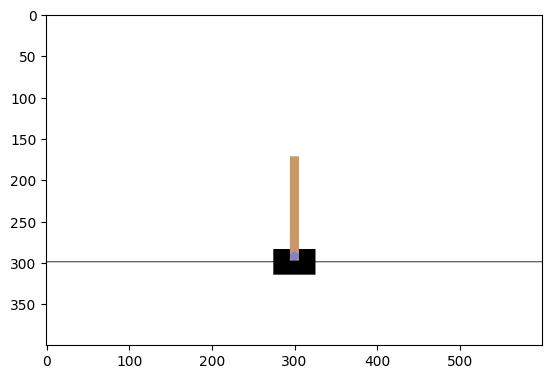

In [ ]:
env = make_env()
env.reset()
plt.imshow(env.render())
state_shape, n_actions = env.observation_space.shape, env.action_space.n

### Построение нейронной сети и агента (5 баллов)

Теперь нам нужно построить нейронную сеть, которая будет преобразовывать наблюдения (состояния) в значения Q-функции (q-values).
Модель не обязательно должна быть огромной. 1-2 скрытых слоя с менее чем 200 нейронами и активацией ReLU, скорее всего, будут достаточны. Использование Batch Normalization и Dropout здесь может ухудшить результаты обучения.

In [ ]:
class DQNAgent(nn.Module):
    def __init__(self, state_shape, n_actions, epsilon=0):

        super().__init__()
        self.epsilon = epsilon
        self.n_actions = n_actions
        self.state_shape = state_shape
        # Определите архитектуру вашей нейронной сети здесь. Убедитесь, что агент полностью содержится в этом классе.
        assert len(state_shape) == 1
        state_dim = state_shape[0]
        ### ВАШ КОД
        input_dim = state_shape[0]
        hidden_dim = 256
        output_dim = n_actions
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim),
        )
        ###ВАШ КОД ЗАКОНЧИЛСЯ


    def forward(self, state_t):
        """
        Принимает наблюдение агента (тензор), возвращает q-значения (тензор)
        :param state_t: пакет состояний, форма = [batch_size, *state_dim=4]
        """
        # Используйте вашу сеть для вычисления q-значений для заданного состояния
        ### ВАШ КОД
        qvalues = self.network(state_t)
        ###ВАШ КОД ЗАКОНЧИЛСЯ

        assert qvalues.requires_grad, "qvalues must be a torch tensor with grad"
        assert (
            len(qvalues.shape) == 2 and
            qvalues.shape[0] == state_t.shape[0] and
            qvalues.shape[1] == n_actions
        )

        return qvalues

    def get_qvalues(self, states):
        """
        Аналогично forward, но работает с numpy-массивами, а не с тензорами
        """
        model_device = next(self.parameters()).device
        states = torch.tensor(states, device=model_device, dtype=torch.float32)
        ### ВАШ КОД
        with torch.no_grad():
          qvalues = self.network(states)
        ### ВАШ КОД ЗАКОНЧИЛСЯ
        return qvalues.data.cpu().numpy()

    def sample_actions(self, qvalues_batches):
        """Выбирает действия на основе q-значений. Использует стратегию epsilon-жадного исследования. """
        epsilon = self.epsilon
        batch_size, n_actions = qvalues_batches.shape

        ### ВАШ КОД
        actions = []
        for qvalues in qvalues_batches:
            if np.random.uniform() <= epsilon:
                action = np.random.randint(n_actions)
            else:
                action = np.argmax(qvalues)
            actions.append(action)
        return np.array(actions)
        ### ВАШ КОД ЗАКОНЧИЛСЯ

### Хранение опыта (Experience Replay)
Для этого задания мы предоставляем вам буфер для хранения опыта. Если вы реализовали буфер хранения опыта в прошлой домашней работе, вы можете скопировать его сюда в основной ноутбук **чтобы получить 2 бонусных балла**.

![img](https://github.com/yandexdataschool/Practical_RL/raw/master/yet_another_week/_resource/exp_replay.png)

Интерфейс довольно прост:
* `exp_replay.add(obs, act, rw, next_obs, done)` - сохраняет кортеж (s,a,r,s',done) в буфер
* `exp_replay.sample(batch_size)` - возвращает наблюдения, действия, награды, следующие наблюдения и флаги завершения эпизода для `batch_size` случайных образцов.
* `len(exp_replay)` - возвращает количество элементов, хранящихся в буфере воспроизведения.

In [ ]:
import random
class ReplayBuffer(object):
    def __init__(self, size):
        """Создаёт буфер воспроизведения.
        Параметры
        ----------
        size: int
            Максимальное количество переходов, которые можно хранить в буфере.
            При переполнении буфера старые записи удаляются.
        """
        self._storage = []
        self._maxsize = size
        self._next_idx = 0

    def __len__(self):
        return len(self._storage)

    def add(self, obs_t, action, reward, obs_tp1, done):
        data = (obs_t, action, reward, obs_tp1, done)

        if self._next_idx >= len(self._storage):
            self._storage.append(data)
        else:
            self._storage[self._next_idx] = data
        self._next_idx = (self._next_idx + 1) % self._maxsize

    def _encode_sample(self, idxes):
        obses_t, actions, rewards, obses_tp1, dones = [], [], [], [], []
        for i in idxes:
            data = self._storage[i]
            obs_t, action, reward, obs_tp1, done = data
            obses_t.append(np.asarray(obs_t))
            actions.append(np.asarray(action))
            rewards.append(reward)
            obses_tp1.append(np.asarray(obs_tp1))
            dones.append(done)
        return (
            np.array(obses_t),
            np.array(actions),
            np.array(rewards),
            np.array(obses_tp1),
            np.array(dones),
        )

    def sample(self, batch_size):
        """Выбирает случайную партию переходов из буфера.
        Параметры
        ----------
        batch_size: int
            Сколько переходов нужно выбрать.
        Возвращает
        -------
        obs_batch: np.array
            партия наблюдений
        act_batch: np.array
            партия действий, выполненных в состоянии obs_batch
        rew_batch: np.array
            вознаграждения, полученные в результате выполнения act_batch
        next_obs_batch: np.array
            следующие наблюдения после выполнения act_batch
        done_mask: np.array
            done_mask[i] = 1, если выполнение act_batch[i] привело к завершению эпизода,
            и 0 в противном случае.
        """
        idxes = [random.randint(0, len(self._storage) - 1) for _ in range(batch_size)]
        return self._encode_sample(idxes)

In [ ]:
#from dqn.replay_buffer import ReplayBuffer
exp_replay = ReplayBuffer(10)

for _ in range(30):
    exp_replay.add(env.reset()[0], env.action_space.sample(), 1.0, env.reset()[0], done=False)

obs_batch, act_batch, reward_batch, next_obs_batch, is_done_batch = exp_replay.sample(5)

assert len(exp_replay) == 10, "размер буфера опыта должен быть 10, так как это максимальная емкость"

### Play and record (3 балла)

In [ ]:
def play_and_record(initial_state, agent, env, exp_replay, n_steps=1):
    """
    Играет в игру ровно n_steps шагов, записывая каждый кортеж (s,a,r,s', done) в буфер воспроизведения.
    Всякий раз, когда игра заканчивается (terminated или truncated), добавляется запись с done=terminated и игра сбрасывается.
    Гарантируется, что среда имеет terminated=False при передаче в эту функцию.

    НЕ СБРАСЫВАЙТЕ СРЕДУ, ЕСЛИ ОНА НЕ ЗАВЕРШЕНА (done)

    :returns: возвращает сумму наград за время игры и состояние, в котором осталась среда
    """
    s = initial_state
    sum_rewards = 0

    # Играйте в игру в течение n_steps, как указано в инструкциях выше
    ### ВАШ КОД
    for _ in range(n_steps):
        qvalues = agent.get_qvalues([s])
        action = agent.sample_actions(qvalues)[0]

        next_s, r, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        exp_replay.add(s, action, r, next_s, done=done)

        sum_rewards += r
        if done:
            s, _ = env.reset()
        else:
             s = next_s
    ###ВАШ КОД ЗАКОНЧИЛСЯ

    return sum_rewards, s

In [ ]:
# тестирование вашего кода.
exp_replay = ReplayBuffer(2000)

state, _ = env.reset()
state_dim = env.observation_space.shape

agent = DQNAgent(state_dim, n_actions, epsilon=1).to(device)
play_and_record(state, agent, env, exp_replay, n_steps=1000)

# если вы используете свой собственный буфер опыта, некоторые из этих тестов могут потребовать корректировки.
# просто убедитесь, что вы понимаете, что делает ваш код
assert len(exp_replay) == 1000, \
    "play_and_record должен был добавить ровно 1000 шагов, " \
    "но вместо этого добавил %i" % len(exp_replay)
is_dones = list(zip(*exp_replay._storage))[-1]

assert 0 < np.mean(is_dones) < 0.1, \
    "Пожалуйста, убедитесь, что вы перезапускаете игру, когда она 'завершена', и " \
    "правильно записываете флаг is_done в буфер. Получена частота is_done %f за " \
    "%i шагов. [Если вы считаете, что вам просто не повезло, просто перезапустите тест]" % (
        np.mean(is_dones), len(exp_replay))

for _ in range(100):
    obs_batch, act_batch, reward_batch, next_obs_batch, is_done_batch = exp_replay.sample(10)
    assert obs_batch.shape == next_obs_batch.shape == (10,) + state_shape
    assert act_batch.shape == (10,), \
        "пакет действий должен иметь форму (10,), но имеет %s" % str(act_batch.shape)
    assert reward_batch.shape == (10,), \
        "пакет наград должен иметь форму (10,), но имеет %s" % str(reward_batch.shape)
    assert is_done_batch.shape == (10,), \
        "пакет is_done должен иметь форму (10,), но имеет %s" % str(is_done_batch.shape)
    assert [int(i) in (0, 1) for i in is_dones], \
        "is_done должен быть строго True или False"
    assert [0 <= a < n_actions for a in act_batch], "действия должны быть в диапазоне [0, n_actions)"

print("Отлично!")

Отлично!


### Целевые сети (Target Networks)

Мы также используем так называемую "целевую сеть" — копию весов нейронной сети, которая используется для вычисления опорных Q-значений:

Сама сеть является точной копией сети агента, но ее параметры не обучаются. Вместо этого они периодически копируются сюда из основной сети агента.

$$ Q_{reference}(s,a) = r + \gamma \cdot \max _{a'} Q_{target}(s',a') $$

![img](https://github.com/yandexdataschool/Practical_RL/raw/master/yet_another_week/_resource/target_net.png)

In [ ]:
agent = DQNAgent(state_shape, n_actions, epsilon=0.5).to(device)
target_network = DQNAgent(agent.state_shape, agent.n_actions, epsilon=0.5).to(device)
# Это то, как вы можете загрузить веса из агента в целевую сеть
target_network.load_state_dict(agent.state_dict())

<All keys matched successfully>

### Обучение с помощью Q-обучения, TD-loss (3 балла)
Здесь мы напишем функцию, аналогичную `agent.update` из табличного Q-обучения.

Вычислим ошибку TD для Q-обучения:

$$ L = { 1 \over N} \sum_i [ Q_{\theta}(s,a) - Q_{reference}(s,a) ] ^2 $$

Где Q-reference определяется как

$$ Q_{reference}(s,a) = r(s,a) + \gamma \cdot max_{a'} Q_{target}(s', a') $$

Где
* $Q_{target}(s',a')$ обозначает Q-значение следующего состояния и следующего действия, предсказанное __целевой сетью__
* $s, a, r, s'$ — текущее состояние, действие, награда и следующее состояние соответственно
* $\gamma$ — коэффициент дисконтирования, определенный двумя ячейками выше.


__Примечание 1:__ Ниже приведен пример входных данных. Не стесняйтесь экспериментировать с ним перед написанием функции.

__Примечание 2:__ Функция `compute_td_loss` является источником 99% ошибок в этой домашней работе. Если награда не улучшается, часто помогает пройтись по ней построчно [с резиновой уткой](https://rubberduckdebugging.com/).

In [ ]:
def compute_td_loss(states, actions, rewards, next_states, is_done,
                    agent, target_network,
                    gamma=0.99,
                    check_shapes=False,
                    device=device):
    """ Вычислите TD-ошибку, используя только операции torch. Используйте приведенные выше формулы. """
    states = torch.tensor(states, device=device, dtype=torch.float32)    # shape: [batch_size, *state_shape]
    actions = torch.tensor(actions, device=device, dtype=torch.int64)    # shape: [batch_size]
    rewards = torch.tensor(rewards, device=device, dtype=torch.float32)  # shape: [batch_size]
    # shape: [batch_size, *state_shape]
    next_states = torch.tensor(next_states, device=device, dtype=torch.float)
    is_done = torch.tensor(
        is_done.astype('float32'),
        device=device,
        dtype=torch.float32,
    )  # shape: [batch_size]
    is_not_done = 1 - is_done

    # получаем q-значения для всех действий в текущих состояниях
    predicted_qvalues = agent(states)  # shape: [batch_size, n_actions]

    # вычисляем q-значения для всех действий в следующих состояниях
    ### ВАШ КОД
    predicted_next_qvalues = target_network(next_states) # shape: [batch_size, n_actions]
    ###ВАШ КОД ЗАКОНЧИЛСЯ

    # выбираем q-значения для выбранных действий
    predicted_qvalues_for_actions = predicted_qvalues[range(len(actions)), actions]  # shape: [batch_size]

    # вычисляем V*(next_states) с использованием предсказанных следующих q-значений
    ### ВАШ КОД
    next_state_values = predicted_next_qvalues.max(dim=1)[0]
    ###ВАШ КОД ЗАКОНЧИЛСЯ

    assert next_state_values.dim() == 1 and next_state_values.shape[0] == states.shape[0], \
        "должно предсказываться одно значение на состояние"

    # вычисляем "целевые q-значения" для потерь - это то, что внутри квадратных скобок в приведенной выше формуле.
    # для последнего состояния используем упрощенную формулу: Q(s,a) = r(s,a), так как s' не существует
    # вы можете умножить значения следующего состояния на is_not_done, чтобы добиться этого.
    ### ВАШ КОД
    target_qvalues_for_actions = rewards + gamma * next_state_values * is_not_done
    ###ВАШ КОД ЗАКОНЧИЛСЯ

    # среднеквадратичная ошибка потерь для минимизации. detach чтобы target_network не обучался при обратном проходе
    loss = torch.mean((predicted_qvalues_for_actions - target_qvalues_for_actions.detach()) ** 2)

    if check_shapes:
        assert predicted_next_qvalues.data.dim() == 2, \
            "убедитесь, что вы предсказали q-значения для всех действий в следующем состоянии"
        assert next_state_values.data.dim() == 1, \
            "убедитесь, что вы вычислили V(s') как максимум только по оси действий, а не по всем осям"
        assert target_qvalues_for_actions.data.dim() == 1, \
            "что-то не так с целевыми q-значениями, они должны быть вектором"

    return loss

Проверка работоспособности

In [ ]:
obs_batch, act_batch, reward_batch, next_obs_batch, is_done_batch = exp_replay.sample(10)

loss = compute_td_loss(obs_batch, act_batch, reward_batch, next_obs_batch, is_done_batch,
                       agent, target_network,
                       gamma=0.99, check_shapes=True)
loss.backward()

assert loss.requires_grad and tuple(loss.data.size()) == (), \
    "вы должны вернуть скалярную потерю - среднее значение по батчу"
assert np.any(next(agent.parameters()).grad.data.cpu().numpy() != 0), \
    "потеря должна быть дифференцируемой по отношению к весам сети"
assert np.all(next(target_network.parameters()).grad is None), \
    "целевая сеть не должна иметь градиентов"

### Основной цикл обучения (3 балла)

Пришло время собрать все вместе и посмотреть, научится ли агент чему-нибудь.

In [ ]:
from tqdm import trange
from IPython.display import clear_output
import matplotlib.pyplot as plt

In [ ]:
seed = 42 # <YOUR CODE: your favourite random seed>
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

In [ ]:
state_dim = env.observation_space.shape
n_actions = env.action_space.n
state, _ = env.reset(seed=seed)

agent = DQNAgent(state_dim, n_actions, epsilon=1).to(device)
target_network = DQNAgent(state_dim, n_actions, epsilon=1).to(device)
target_network.load_state_dict(agent.state_dict())

<All keys matched successfully>

In [ ]:
from dqn.utils import is_enough_ram, linear_decay

REPLAY_BUFFER_SIZE = 10**4

exp_replay = ReplayBuffer(REPLAY_BUFFER_SIZE)
for i in range(100):
    if not is_enough_ram(min_available_gb=0.1):
        print("""
            Доступно менее 100 Мб оперативной памяти.
            Убедитесь, что размер буфера не слишком велик.
            Также проверьте, возможно, другие процессы сильно потребляют оперативную память.
            """
             )
        break
    play_and_record(state, agent, env, exp_replay, n_steps=10**2)
    if len(exp_replay) == REPLAY_BUFFER_SIZE:
        break
print(len(exp_replay))

10000


In [ ]:
# # для чего-то более сложного, чем CartPole

# timesteps_per_epoch = 1
# batch_size = 32
# total_steps = 3 * 10**6
# decay_steps = 1 * 10**6

# opt = torch.optim.Adam(agent.parameters(), lr=1e-4)

# init_epsilon = 1
# final_epsilon = 0.1

# loss_freq = 20
# refresh_target_network_freq = 1000
# eval_freq = 5000

# max_grad_norm = 5000

In [ ]:
timesteps_per_epoch = 1
batch_size = 32
total_steps = 4 * 10**4
decay_steps = 1 * 10**4

opt = torch.optim.Adam(agent.parameters(), lr=1e-4)

init_epsilon = 1
final_epsilon = 0.1

loss_freq = 20
refresh_target_network_freq = 100
eval_freq = 1000

max_grad_norm = 5000

In [ ]:
mean_rw_history = []
td_loss_history = []
grad_norm_history = []
initial_state_v_history = []
step = 0

In [ ]:
import time

def wait_for_keyboard_interrupt():
    try:
        while True:
            time.sleep(1)
    except KeyboardInterrupt:
        pass

размер буфера = 10000, epsilon = 0.10000


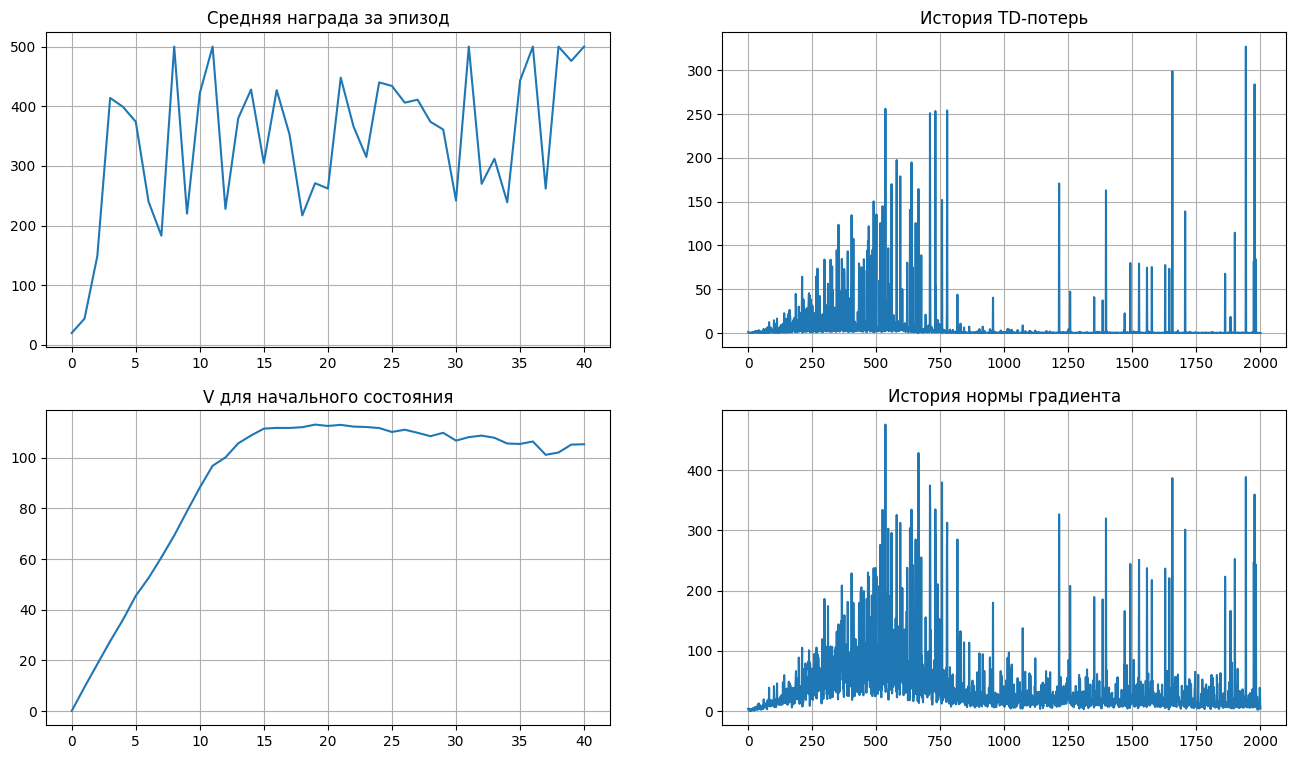

100%|██████████| 40001/40001 [03:14<00:00, 205.69it/s]


In [ ]:
state, _ = env.reset()
with trange(step, total_steps + 1) as progress_bar:
    for step in progress_bar:
        if not is_enough_ram():
            print('доступно менее 100 Мб оперативной памяти, приостановка')
            print('убедитесь, что все в порядке, и используйте KeyboardInterrupt для продолжения')
            wait_for_keyboard_interrupt()

        agent.epsilon = linear_decay(init_epsilon, final_epsilon, step, decay_steps)

        # играем
        _, state = play_and_record(state, agent, env, exp_replay, timesteps_per_epoch)

        # обучаемся
        ### ВАШ КОД: возьмите сэмпл размера batch_size из буфера опыта
        obs_batch, act_batch, reward_batch, next_obs_batch, is_done_batch = exp_replay.sample(batch_size)
        ###ВАШ КОД ЗАКОНЧИЛСЯ

        ### ВАШ КОД: вычислите TD-потери
        loss = compute_td_loss(obs_batch, act_batch, reward_batch, next_obs_batch, is_done_batch,
                    agent, target_network)
        ###ВАШ КОД ЗАКОНЧИЛСЯ

        loss.backward()
        grad_norm = nn.utils.clip_grad_norm_(agent.parameters(), max_grad_norm)
        opt.step()
        opt.zero_grad()

        if step % loss_freq == 0:
            td_loss_history.append(loss.data.cpu().item())
            grad_norm_history.append(grad_norm.cpu().item())

        if step % refresh_target_network_freq == 0:
            # Загрузите веса агента в целевую сеть
            ### ВАШ КОД
            target_network.load_state_dict(agent.state_dict())
            ###ВАШ КОД ЗАКОНЧИЛСЯ

        if step % eval_freq == 0:
            mean_rw_history.append(evaluate(
                make_env(), agent, n_games=3, greedy=True, t_max=1000, seed=step)
            )
            initial_state_q_values = agent.get_qvalues(
                [make_env().reset(seed=step)[0]]
            )
            initial_state_v_history.append(np.max(initial_state_q_values))

            clear_output(True)
            print("размер буфера = %i, epsilon = %.5f" %
                (len(exp_replay), agent.epsilon))

            plt.figure(figsize=[16, 9])

            plt.subplot(2, 2, 1)
            plt.title("Средняя награда за эпизод")
            plt.plot(mean_rw_history)
            plt.grid()

            assert not np.isnan(td_loss_history[-1])
            plt.subplot(2, 2, 2)
            plt.title("История TD-потерь")
            plt.plot(td_loss_history)
            plt.grid()

            plt.subplot(2, 2, 3)
            plt.title("V для начального состояния")
            plt.plot(initial_state_v_history)
            plt.grid()

            plt.subplot(2, 2, 4)
            plt.title("История нормы градиента")
            plt.plot(grad_norm_history)
            plt.grid()

            plt.show()

In [ ]:
final_score = evaluate(
  make_env(),
  agent, n_games=30, greedy=True, t_max=1000
)
print('итоговый результат:', final_score)
assert final_score > 300, 'недостаточно хорошо для DQN'
print('Отлично')

итоговый результат: 430.9
Отлично


### Сравнение предсказанных агентом V-значений с их оценками методом Монте-Карло (2 балла)

In [ ]:
from dqn.analysis import play_and_log_episode

eval_env = make_env()
record = play_and_log_episode(eval_env, agent)
print('общая награда за эпизод:', np.sum(record['rewards']))
for key in record:
    print(key)

общая награда за эпизод: 500.0
states
qvalues
actions
rewards
episode_finished


Построив scatter plot v_mc против v_agent, мы можем визуально оценить, насколько хорошо предсказания агента согласуются с реальным опытом. Если агент обучен хорошо, точки должны лежать близко к линии x=y. Отклонения могут указывать на переоценку или недооценку агентом ценности состояний.

In [ ]:
def get_discounted_returns(rewards, gamma) -> list[float]:
    """
    Вычисляет G[t] для каждого t, учитывая награды и гамму.

    Совет: Итерируйте в обратном порядке по наградам и используйте следующее соотношение:
    G[t] = r[t] + gamma * G[t + 1]
    """
    ### ВАШ КОД
    returns = []
    G = 0
    for r in reversed(rewards):
        G = r + gamma * G
        returns.append(G)
    returns.reverse()
    return returns
    ###ВАШ КОД ЗАКОНЧИЛСЯ

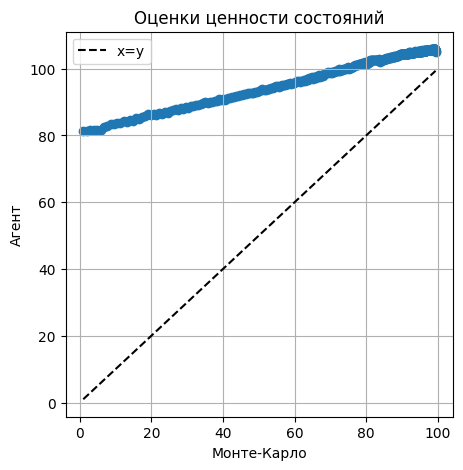

In [ ]:
fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(1, 1, 1)

# Вычисляем V-значения по Монте-Карло и по агенту
v_mc = get_discounted_returns(record['rewards'], 0.99)#np.array([np.sum(record['rewards'][i:] * (0.99 ** np.arange(len(record['rewards']) - i)))
#                 for i in range(len(record['rewards']))])
v_agent = np.max(record['qvalues'], axis=1)

ax.scatter(v_mc, v_agent)
ax.plot(sorted(v_mc), sorted(v_mc),
       'black', linestyle='--', label='x=y')

ax.grid()
ax.legend()
ax.set_title('Оценки ценности состояний')
ax.set_xlabel('Монте-Карло')
ax.set_ylabel('Агент')

plt.show()

# Бонус: Дуэльный DQN и Double TD-loss (2+2 балла)

In [ ]:
import torch
import torch.nn as nn
import numpy as np

class DuelingDQNHead(nn.Module):
    def __init__(self, input_dim, n_actions):
        super(DuelingDQNHead, self).__init__()
        ### ВАШ КОД
        # advantage_stream: линейный слой -> ReLU -> линейный слой -> n_actions
        # value_stream: линейный слой -> ReLU -> линейный слой -> 1
        hidden_dim = 256
        self.advantage_stream = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, n_actions),
        )
        self.value_stream = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )
        ###ВАШ КОД ЗАКОНЧИЛСЯ

    def forward(self, x):
        ### ВАШ КОД
        vvalues = self.value_stream(x)
        advantages = self.advantage_stream(x)

        mean_advantages = advantages.mean(dim=1, keepdim=True)
        centered_advantages = advantages - mean_advantages

        return vvalues + centered_advantages
###ВАШ КОД ЗАКОНЧИЛСЯ

In [ ]:
class DuelingDQN(nn.Module):
    def __init__(self, state_shape, n_actions):
        super(DuelingDQN, self).__init__()
        state_dim = state_shape[0]
        ### ВАШ КОД
        hidden_dim = 192
        # feature_extractor: линейный -> ReLU -> линейный -> ReLU
        self.feature_extractor = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )
        ###ВАШ КОД ЗАКОНЧИЛСЯ
        self.dueling_head = DuelingDQNHead(hidden_dim, n_actions)

    def forward(self, x):
        features = self.feature_extractor(x)
        qvals = self.dueling_head(features)
        return qvals

In [ ]:
class DuelingDQNAgent(nn.Module):
    def __init__(self, state_shape, n_actions, epsilon=0):
        super().__init__()
        self.epsilon = epsilon
        self.n_actions = n_actions
        self.state_shape = state_shape
        assert len(state_shape) == 1
        ### ВАШ КОД
        # Используйте DuelingDQN как q_network
        self.q_network = DuelingDQN(state_shape, n_actions)
        ###ВАШ КОД ЗАКОНЧИЛСЯ

    def forward(self, state_t):
        """
        Принимает наблюдение агента (тензор), возвращает q-значения (тензор)
        :param state_t: пакет состояний, форма = [batch_size, *state_dim=4]
        """
        qvalues = self.q_network(state_t)
        #UPD: этот assert можно закомментить на время обучения с double DQN
        #assert qvalues.requires_grad, "qvalues must be a torch tensor with grad"
        assert (
            len(qvalues.shape) == 2 and
            qvalues.shape[0] == state_t.shape[0] and
            qvalues.shape[1] == self.n_actions
        )
        return qvalues

    def get_qvalues(self, states):
        """
        Аналогично forward, но работает с numpy-массивами, а не с тензорами
        """
        model_device = next(self.parameters()).device
        states = torch.tensor(states, device=model_device, dtype=torch.float32)
        qvalues = self.forward(states)
        return qvalues.data.cpu().numpy()

    def sample_actions(self, qvalues_batches, greedy=False):
        """
        Выбирает действия на основе q-значений. Использует стратегию epsilon-жадного исследования.
        """
        if greedy:
            return qvalues_batches.argmax(axis=-1)

        epsilon = self.epsilon
        batch_size, n_actions = qvalues_batches.shape

        ### ВАШ КОД
        actions = []
        for qvalues in qvalues_batches:
            if np.random.uniform() <= epsilon:
                action = np.random.randint(n_actions)
            else:
                action = np.argmax(qvalues)
            actions.append(action)
        return np.array(actions)
        ### ВАШ КОД ЗАКОНЧИЛСЯ

In [ ]:
def compute_td_loss_double(
    states,
    actions,
    rewards,
    next_states,
    is_done,
    agent: nn.Module,
    target_network: nn.Module,
    gamma: float = 0.99,
    check_shapes=False,
):
    states = torch.tensor(states, device=device, dtype=torch.float32)    # shape: [batch_size, *state_shape]
    actions = torch.tensor(actions, device=device, dtype=torch.int64)    # shape: [batch_size]
    rewards = torch.tensor(rewards, device=device, dtype=torch.float32)  # shape: [batch_size]
    # shape: [batch_size, *state_shape]
    next_states = torch.tensor(next_states, device=device, dtype=torch.float)
    is_done = torch.tensor(
        is_done.astype('float32'),
        device=device,
        dtype=torch.float32,
    )  # shape: [batch_size]
    is_not_done = 1 - is_done

    predicted_qvalues = agent(states)  # форма: [batch_size, n_actions]

    # вычисляем q-значения для всех действий в следующих состояниях
    ### ВАШ КОД
    # этот шаг не будет использован в обучении, потому что операция argmax не дифференцируема, а predicted_next_qvalues_agent используется только для этого
    predicted_next_qvalues_agent = agent(next_states)
    with torch.no_grad():
        predicted_next_qvalues_target = target_network(next_states)
    ###ВАШ КОД ЗАКОНЧИЛСЯ

    # выбираем q-значения для выбранных действий
    predicted_qvalues_for_actions = predicted_qvalues[
        range(len(actions)), actions
    ]  # форма: [batch_size]

    # вычисляем V*(next_states) используя предсказанные q-значения следующих состояний
    ### ВАШ КОД
    max_action = predicted_next_qvalues_agent.argmax(dim=1)
    next_state_values = predicted_next_qvalues_target[range(len(actions)), max_action]
    ###ВАШ КОД ЗАКОНЧИЛСЯ

    if check_shapes:
        assert (
            next_state_values.dim() == 1
            and next_state_values.shape[0] == states.shape[0]
        ), "должно предсказываться одно значение на состояние"
        assert not next_state_values.requires_grad

    # вычисляем "целевые q-значения" для ошибки - это то, что в квадратных скобках в формуле выше.
    # в последнем состоянии используем упрощенную формулу: Q(s,a) = r(s,a), так как s' не существует
    ### ВАШ КОД
    target_qvalues_for_actions = rewards + gamma * next_state_values * is_not_done
    ###ВАШ КОД ЗАКОНЧИЛСЯ

    # среднеквадратичная ошибка для минимизации
    td_errors = predicted_qvalues_for_actions - target_qvalues_for_actions
    loss = torch.mean(td_errors ** 2)

    if check_shapes:
        assert (
            predicted_next_qvalues_target.data.dim() == 2
        ), "убедитесь, что вы предсказали q-значения для всех действий в следующем состоянии"
        assert (
            next_state_values.data.dim() == 1
        ), "убедитесь, что вы вычислили V(s') как максимум только по оси действий, а не по всем осям"
        assert (
            target_qvalues_for_actions.data.dim() == 1
        ), "что-то не так с целевыми q-значениями, они должны быть вектором"

    assert not torch.isnan(loss)
    assert not torch.isinf(loss)

    return loss

In [ ]:
timesteps_per_epoch = 5
batch_size = 64
total_steps = 4 * 10**4
decay_steps = 1 * 10**3

init_epsilon = 1
final_epsilon = 0.1

loss_freq = 20
refresh_target_network_freq = 300
eval_freq = 1000

max_grad_norm = 50

REPLAY_BUFFER_SIZE = 10**4

In [ ]:
env = make_env()
env.reset()
state_shape, n_actions = env.observation_space.shape, env.action_space.n

# Инициализируем агента и целевую сеть
dueling_agent = DuelingDQNAgent(state_shape, n_actions, epsilon=0.1).to(device)
dueling_target_network = DuelingDQNAgent(state_shape, n_actions, epsilon=0.1).to(device)
dueling_target_network.q_network.load_state_dict(dueling_agent.q_network.state_dict())

agent=dueling_agent  #если хотите потестировать Dueling DQN
target_network = dueling_target_network

opt = torch.optim.Adam(agent.parameters(), lr=1e-4)
exp_replay = ReplayBuffer(REPLAY_BUFFER_SIZE)


In [ ]:
# exp_replay = ReplayBuffer(REPLAY_BUFFER_SIZE)
# for i in range(100):
#     play_and_record(state, agent, env, exp_replay, n_steps=10**2)

In [ ]:
mean_rw_history = []
td_loss_history = []
grad_norm_history = []
initial_state_v_history = []
step = 0

размер буфера = 10000, epsilon = 0.10000


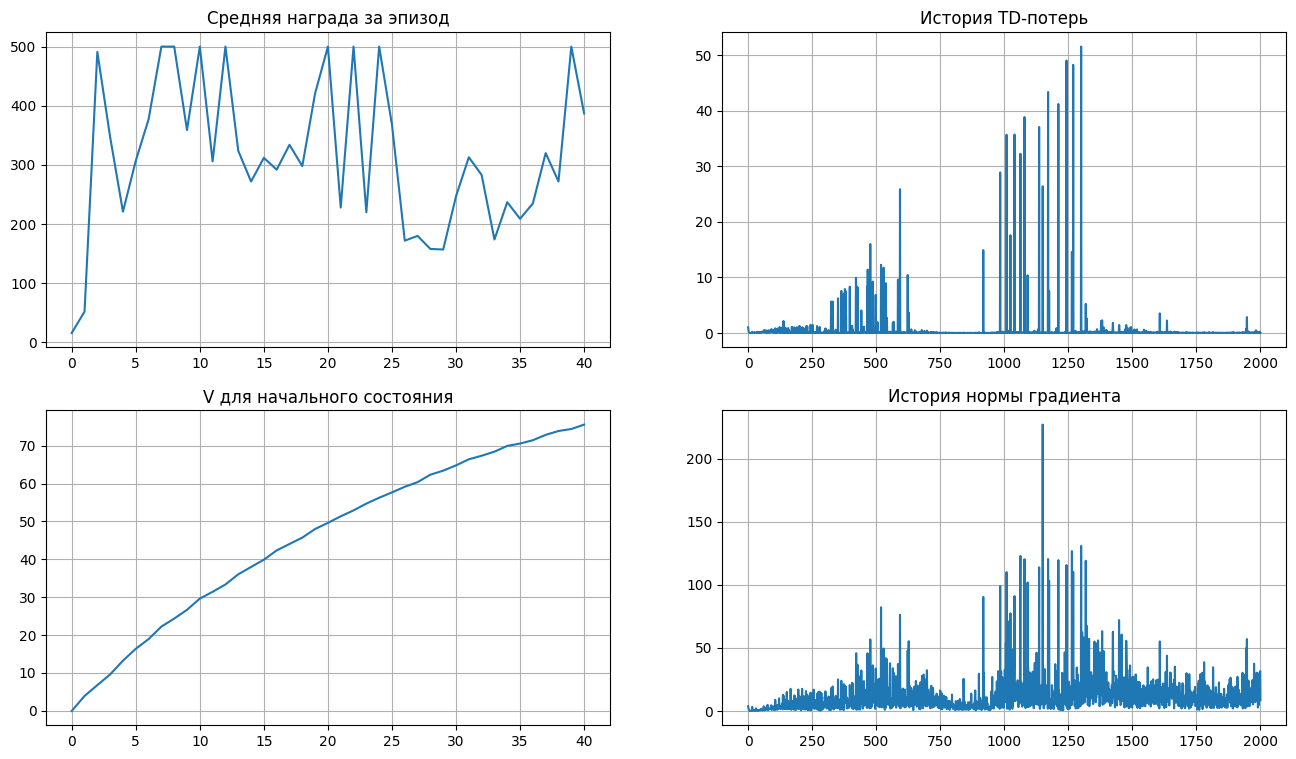

100%|██████████| 40001/40001 [08:04<00:00, 82.48it/s] 


In [ ]:
state, _ = env.reset()
with trange(step, total_steps + 1) as progress_bar:
    for step in progress_bar:
        if not is_enough_ram():
            print('доступно менее 100 Мб оперативной памяти, приостановка')
            print('убедитесь, что все в порядке, и используйте KeyboardInterrupt для продолжения')
            wait_for_keyboard_interrupt()

        agent.epsilon = linear_decay(init_epsilon, final_epsilon, step, decay_steps)

        # играем
        _, state = play_and_record(state, agent, env, exp_replay, timesteps_per_epoch)

        # обучаемся
        ### ВАШ КОД: возьмите сэмпл размера batch_size из буфера опыта
        obs_batch, act_batch, reward_batch, next_obs_batch, is_done_batch = exp_replay.sample(batch_size)

        assert not np.isnan(obs_batch).any(), "obs_batch содержит NaN"
        assert not np.isnan(reward_batch).any(), "reward_batch содержит NaN"
        assert not np.isnan(next_obs_batch).any(), "next_obs_batch содержит NaN"
        assert not np.isnan(is_done_batch).any(), "is_done_batch содержит NaN"

        assert not np.isinf(obs_batch).any(), "obs_batch содержит inf"
        assert not np.isinf(reward_batch).any(), "reward_batch содержит inf"
        assert not np.isinf(next_obs_batch).any(), "next_obs_batch содержит inf"
        assert not np.isinf(is_done_batch).any(), "is_done_batch содержит inf"
        ###ВАШ КОД ЗАКОНЧИЛСЯ

        ### ВАШ КОД: вычислите TD-потери
        loss = compute_td_loss_double(obs_batch, act_batch, reward_batch, next_obs_batch, is_done_batch,
                    agent, target_network)
        ###ВАШ КОД ЗАКОНЧИЛСЯ

        loss.backward()

        total_norm = 0
        for p in agent.parameters():
            if p.grad is not None:
                param_norm = p.grad.data.norm(2)
                total_norm += param_norm.item() ** 2
        total_norm = total_norm ** 0.5
        assert not np.isnan(total_norm), "Gradient norm is NaN"
        assert not np.isinf(total_norm), "Gradient norm is inf"

        grad_norm = nn.utils.clip_grad_norm_(agent.parameters(), max_grad_norm)
        opt.step()
        opt.zero_grad()

        if step % loss_freq == 0:
            td_loss_history.append(loss.data.cpu().item())
            grad_norm_history.append(grad_norm.cpu().item())

        if step % refresh_target_network_freq == 0:
            # Загрузите веса агента в целевую сеть
            ### ВАШ КОД
            target_network.q_network.load_state_dict(agent.q_network.state_dict())
            ###ВАШ КОД ЗАКОНЧИЛСЯ

        if step % eval_freq == 0:
            mean_rw_history.append(evaluate(
                make_env(), agent, n_games=3, greedy=True, t_max=1000, seed=step)
            )
            initial_state_q_values = agent.get_qvalues(
                [make_env().reset(seed=step)[0]]
            )
            initial_state_v_history.append(np.max(initial_state_q_values))

            clear_output(True)
            print("размер буфера = %i, epsilon = %.5f" %
                (len(exp_replay), agent.epsilon))

            plt.figure(figsize=[16, 9])

            plt.subplot(2, 2, 1)
            plt.title("Средняя награда за эпизод")
            plt.plot(mean_rw_history)
            plt.grid()

            assert not np.isnan(td_loss_history[-1])
            plt.subplot(2, 2, 2)
            plt.title("История TD-потерь")
            plt.plot(td_loss_history)
            plt.grid()

            plt.subplot(2, 2, 3)
            plt.title("V для начального состояния")
            plt.plot(initial_state_v_history)
            plt.grid()

            plt.subplot(2, 2, 4)
            plt.title("История нормы градиента")
            plt.plot(grad_norm_history)
            plt.grid()

            plt.show()

In [ ]:
final_score = evaluate(
  make_env(),
  agent, n_games=30, greedy=True, t_max=1000
)
print('итоговый результат:', final_score)
assert final_score > 300, 'недостаточно хорошо для DQN'
print('Отлично')

итоговый результат: 396.6333333333333
Отлично


In [ ]:
import gymnasium as gym
import matplotlib.pyplot as plt

env = gym.make("CartPole-v1", render_mode="rgb_array")
obs, _ = env.reset()
frames = []

done = False
while not done:
    frames.append(env.render())
    qvalues = agent.get_qvalues([obs])
    action = qvalues.argmax(axis=-1)[0]
    obs, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated

env.close()

import imageio

imageio.mimsave('cartpole_agent.mp4', frames, fps=30, macro_block_size=None)

from IPython.display import Video
Video("cartpole_agent.mp4", embed=True)

общая награда за эпизод: 462.0


Text(0, 0.5, 'Агент')

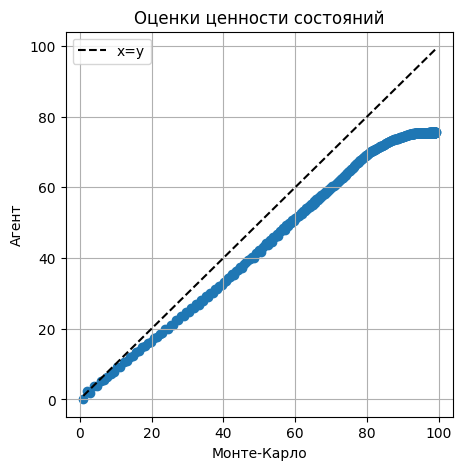

In [ ]:
eval_env = make_env()
record = play_and_log_episode(eval_env, agent)
print('общая награда за эпизод:', np.sum(record['rewards']))

fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(1, 1, 1)

# Вычисляем V-значения по Монте-Карло и по агенту
v_mc = get_discounted_returns(record['rewards'], 0.99)#np.array([np.sum(record['rewards'][i:] * (0.99 ** np.arange(len(record['rewards']) - i)))
#                 for i in range(len(record['rewards']))])
v_agent = np.max(record['qvalues'], axis=1)

ax.scatter(v_mc, v_agent)
ax.plot(sorted(v_mc), sorted(v_mc),
       'black', linestyle='--', label='x=y')

ax.grid()
ax.legend()
ax.set_title('Оценки ценности состояний')
ax.set_xlabel('Монте-Карло')
ax.set_ylabel('Агент')

In [ ]:
torch.save(agent.state_dict(), 'last_state_dict.pt')


# Бонус II (8 баллов). Примените модификации к DQN.

* [Prioritized experience replay](https://arxiv.org/abs/1511.05952) (2 балла, пожалуйста, проверьте наличие эффективных реализаций с открытым исходным кодом)
* [Noisy Nets](https://arxiv.org/abs/1706.10295) (2 балла, пожалуйста, обратите внимание на политику исследования и используется ли эпсилон-жадная политика)
* [Distributional RL](https://arxiv.org/abs/1707.06887) (distributional и distributed здесь означают разные вещи) (2 балла)
* Другие модификации (2 балла в зависимости от сложности)

### Prioritized experience replay

In [ ]:
import os
if not os.path.exists('per'):
    !git clone https://github.com/rlcode/per.git

import sys
if '/content/per' not in sys.path:
    sys.path.append('/content/per')

from prioritized_memory import Memory as PrioritizedReplayBuffer



Cloning into 'per'...
remote: Enumerating objects: 32, done.
remote: Total 32 (delta 0), reused 0 (delta 0), pack-reused 32 (from 1)
Receiving objects: 100% (32/32), 14.59 KiB | 14.59 MiB/s, done.
Resolving deltas: 100% (11/11), done.


In [ ]:
def play_and_record_weighted(initial_state, agent, env, prioritized_exp_replay, n_steps=1):
    """
    Играет в игру ровно n_steps шагов, записывая каждый кортеж (s,a,r,s', done) в буфер воспроизведения.
    Всякий раз, когда игра заканчивается (terminated или truncated), добавляется запись с done=terminated и игра сбрасывается.
    Гарантируется, что среда имеет terminated=False при передаче в эту функцию.

    НЕ СБРАСЫВАЙТЕ СРЕДУ, ЕСЛИ ОНА НЕ ЗАВЕРШЕНА (done)

    :returns: возвращает сумму наград за время игры и состояние, в котором осталась среда
    """
    s = initial_state
    sum_rewards = 0

    for _ in range(n_steps):
        qvalues = agent.get_qvalues([s])
        action = agent.sample_actions(qvalues)[0]

        next_s, r, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        """
        Получаем максимальный приоритет из листьев SumTree (последние capacity элементов дерева)

        При добавлении нового перехода мы не можем сразу посчитать TD-ошибку (для этого нужно обучить сеть на этом переходе).
        Поэтому мы просто даём ему максимальный приоритет, чтобы он гарантированно попал в ближайший обучающий батч.
        После того, как переход попадёт в батч и по нему будет вычислена TD-ошибка, мы обновим его приоритет с помощью метода .update(idx, td_error).
        """
        max_prio = np.max(prioritized_exp_replay.tree.tree[-prioritized_exp_replay.capacity:]) if prioritized_exp_replay.tree.n_entries > 0 else 1.0
        prioritized_exp_replay.add(max_prio, (s, action, r, next_s, done))

        sum_rewards += r
        if done:
            s, _ = env.reset()
        else:
             s = next_s

    return sum_rewards, s

In [ ]:
def compute_td_loss_double_weighted(
    states,
    actions,
    rewards,
    next_states,
    is_done,
    agent: nn.Module,
    target_network: nn.Module,
    weights,
    gamma: float = 0.99,
    check_shapes=False,
):
    states = torch.tensor(states, device=device, dtype=torch.float32)    # shape: [batch_size, *state_shape]
    actions = torch.tensor(actions, device=device, dtype=torch.int64)    # shape: [batch_size]
    rewards = torch.tensor(rewards, device=device, dtype=torch.float32)  # shape: [batch_size]
    # shape: [batch_size, *state_shape]
    next_states = torch.tensor(next_states, device=device, dtype=torch.float)
    is_done = torch.tensor(
        is_done.astype('float32'),
        device=device,
        dtype=torch.float32,
    )  # shape: [batch_size]
    is_not_done = 1 - is_done

    predicted_qvalues = agent(states)  # форма: [batch_size, n_actions]

    # вычисляем q-значения для всех действий в следующих состояниях
    predicted_next_qvalues_agent = agent(next_states)
    with torch.no_grad():
        predicted_next_qvalues_target = target_network(next_states)

    # выбираем q-значения для выбранных действий
    predicted_qvalues_for_actions = predicted_qvalues[
        range(len(actions)), actions
    ]  # форма: [batch_size]

    # вычисляем V*(next_states) используя предсказанные q-значения следующих состояний
    max_action = predicted_next_qvalues_agent.argmax(dim=1)
    next_state_values = predicted_next_qvalues_target[range(len(actions)), max_action]

    target_qvalues_for_actions = rewards + gamma * next_state_values * is_not_done

    td_errors = predicted_qvalues_for_actions - target_qvalues_for_actions
    elementwise_loss = td_errors ** 2
    if weights is not None:
        weights = torch.tensor(weights, device=elementwise_loss.device, dtype=elementwise_loss.dtype)
        loss = torch.mean(elementwise_loss * weights)
    else:
        loss = torch.mean(elementwise_loss)

    if check_shapes:
        assert (
            predicted_next_qvalues_target.data.dim() == 2
        ), "убедитесь, что вы предсказали q-значения для всех действий в следующем состоянии"
        assert (
            next_state_values.data.dim() == 1
        ), "убедитесь, что вы вычислили V(s') как максимум только по оси действий, а не по всем осям"
        assert (
            target_qvalues_for_actions.data.dim() == 1
        ), "что-то не так с целевыми q-значениями, они должны быть вектором"

    return loss, td_errors.detach().cpu().numpy()

In [ ]:
timesteps_per_epoch = 10
batch_size = 256
total_steps = 4 * 10**4
decay_steps = 1 * 10**4

init_epsilon = 1
final_epsilon = 0.1

loss_freq = 20
refresh_target_network_freq = 300
eval_freq = 1000

epsilon=0.1
lr=5e-4

max_grad_norm = 10

REPLAY_BUFFER_SIZE = 10**5

In [ ]:
env = make_env()
env.reset()
state_shape, n_actions = env.observation_space.shape, env.action_space.n

# Инициализируем агента и целевую сеть
agent = DuelingDQNAgent(state_shape, n_actions, epsilon=epsilon).to(device)
target_network = DuelingDQNAgent(state_shape, n_actions, epsilon=epsilon).to(device)
target_network.q_network.load_state_dict(agent.q_network.state_dict())

opt = torch.optim.Adam(agent.parameters(), lr=lr)

In [ ]:
prioritized_exp_replay = PrioritizedReplayBuffer(REPLAY_BUFFER_SIZE)
for i in range(300):
    play_and_record_weighted(state, agent, env, prioritized_exp_replay, n_steps=10**2)

In [ ]:
mean_rw_history = []
td_loss_history = []
grad_norm_history = []
initial_state_v_history = []
step = 0

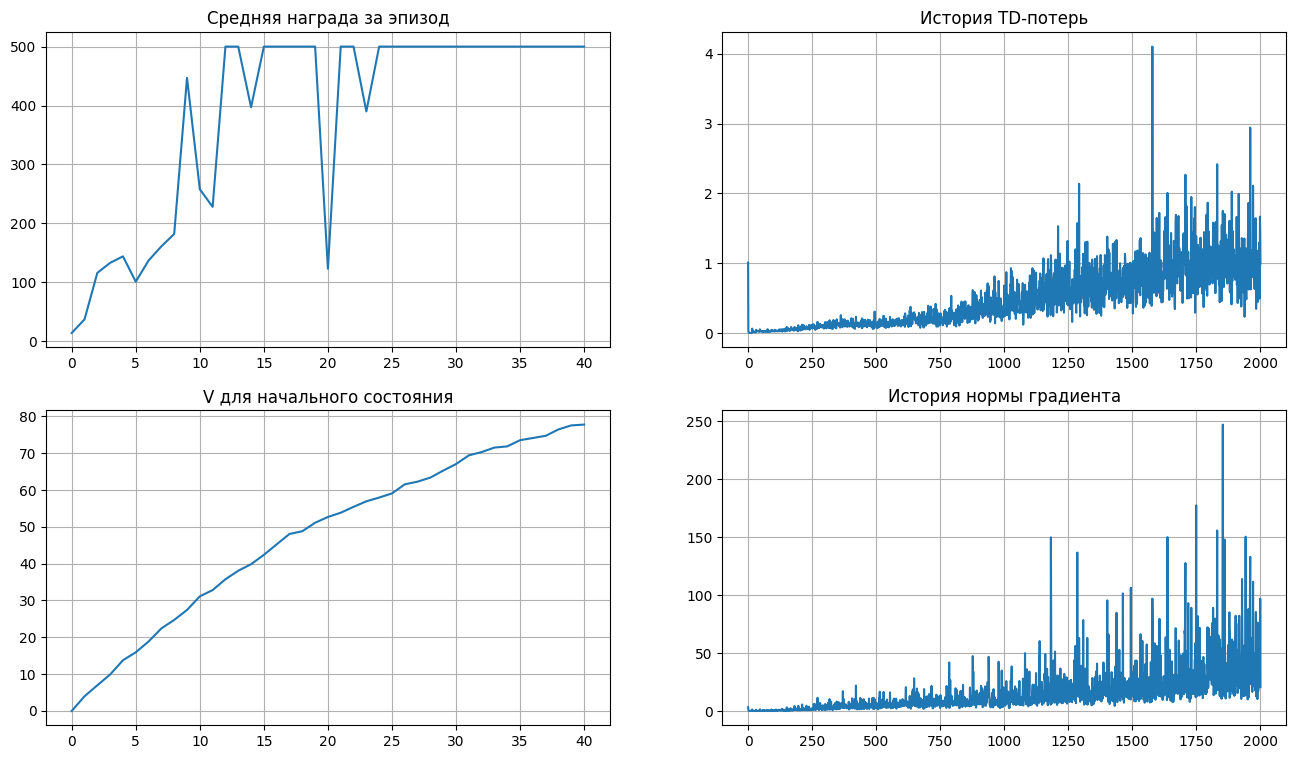

100%|██████████| 40001/40001 [14:37<00:00, 45.57it/s]


In [ ]:
state, _ = env.reset()
with trange(step, total_steps + 1) as progress_bar:
    for step in progress_bar:
        agent.epsilon = linear_decay(init_epsilon, final_epsilon, step, decay_steps)

        # играем
        _, state = play_and_record_weighted(state, agent, env, prioritized_exp_replay, timesteps_per_epoch)

        # обучаемся
        batch, idxs, weights = prioritized_exp_replay.sample(batch_size)
        obs_batch, act_batch, reward_batch, next_obs_batch, is_done_batch = zip(*batch)
        obs_batch = np.array(obs_batch)
        act_batch = np.array(act_batch)
        reward_batch = np.array(reward_batch)
        next_obs_batch = np.array(next_obs_batch)
        is_done_batch = np.array(is_done_batch)
        weights = np.array(weights)

        ### ВАШ КОД: вычислите TD-потери
        loss, td_errors = compute_td_loss_double_weighted(obs_batch, act_batch, reward_batch, next_obs_batch, is_done_batch,
                    agent, target_network, weights)
        ###ВАШ КОД ЗАКОНЧИЛСЯ

        loss.backward()
        grad_norm = nn.utils.clip_grad_norm_(agent.parameters(), max_grad_norm)
        opt.step()
        opt.zero_grad()

        for idx, td_error in zip(idxs, td_errors):
          prioritized_exp_replay.update(idx, td_error)

        if step % loss_freq == 0:
            td_loss_history.append(loss.data.cpu().item())
            grad_norm_history.append(grad_norm.cpu().item())

        if step % refresh_target_network_freq == 0:
            # Загрузите веса агента в целевую сеть
            ### ВАШ КОД
            target_network.q_network.load_state_dict(agent.q_network.state_dict())
            ###ВАШ КОД ЗАКОНЧИЛСЯ

        if step % eval_freq == 0:
            mean_rw_history.append(evaluate(
                make_env(), agent, n_games=3, greedy=True, t_max=1000, seed=step)
            )
            initial_state_q_values = agent.get_qvalues(
                [make_env().reset(seed=step)[0]]
            )
            initial_state_v_history.append(np.max(initial_state_q_values))

            clear_output(True)

            plt.figure(figsize=[16, 9])

            plt.subplot(2, 2, 1)
            plt.title("Средняя награда за эпизод")
            plt.plot(mean_rw_history)
            plt.grid()

            assert not np.isnan(td_loss_history[-1])
            plt.subplot(2, 2, 2)
            plt.title("История TD-потерь")
            plt.plot(td_loss_history)
            plt.grid()

            plt.subplot(2, 2, 3)
            plt.title("V для начального состояния")
            plt.plot(initial_state_v_history)
            plt.grid()

            plt.subplot(2, 2, 4)
            plt.title("История нормы градиента")
            plt.plot(grad_norm_history)
            plt.grid()

            plt.show()

In [ ]:
final_score = evaluate(
  make_env(),
  agent, n_games=30, greedy=True, t_max=1000
)
print('итоговый результат:', final_score)

итоговый результат: 500.0


In [ ]:
import gymnasium as gym
import matplotlib.pyplot as plt

env = gym.make("CartPole-v1", render_mode="rgb_array")
obs, _ = env.reset()
frames = []

done = False
while not done:
    frames.append(env.render())
    qvalues = agent.get_qvalues([obs])
    action = qvalues.argmax(axis=-1)[0]
    obs, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated

env.close()

import imageio

imageio.mimsave('cartpole_agent_prioritized_exp_replay.mp4', frames, fps=30, macro_block_size=None)

from IPython.display import Video
Video("cartpole_agent_prioritized_exp_replay.mp4", embed=True)

общая награда за эпизод: 500.0


Text(0, 0.5, 'Агент')

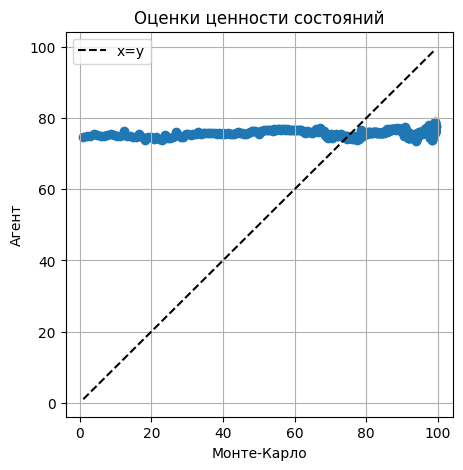

In [ ]:
eval_env = make_env()
record = play_and_log_episode(eval_env, agent)
print('общая награда за эпизод:', np.sum(record['rewards']))

fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(1, 1, 1)

# Вычисляем V-значения по Монте-Карло и по агенту
v_mc = get_discounted_returns(record['rewards'], 0.99)#np.array([np.sum(record['rewards'][i:] * (0.99 ** np.arange(len(record['rewards']) - i)))
#                 for i in range(len(record['rewards']))])
v_agent = np.max(record['qvalues'], axis=1)

ax.scatter(v_mc, v_agent)
ax.plot(sorted(v_mc), sorted(v_mc),
       'black', linestyle='--', label='x=y')

ax.grid()
ax.legend()
ax.set_title('Оценки ценности состояний')
ax.set_xlabel('Монте-Карло')
ax.set_ylabel('Агент')

### Noisy Nets

In [ ]:
def evaluate_noisy(env, agent, n_games=1, t_max=10000, seed=None):
    """ Играет n_games полных игр. Возвращает среднее вознаграждение. """
    rewards = []
    for _ in range(n_games):
        s, _ = env.reset(seed=seed)
        reward = 0
        for _ in range(t_max):
            qvalues = agent.get_qvalues([s])
            action = qvalues.argmax(axis=-1)[0]
            s, r, terminated, truncated, _ = env.step(action)
            reward += r
            if terminated or truncated:
                break
        rewards.append(reward)
    return np.mean(rewards)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class NoisyLinear(nn.Module):
    """
    Реализация "шумного" линейного слоя из статьи [Noisy Networks for Exploration](https://arxiv.org/abs/1706.10295).

    Основная идея

    Вместо обычного слоя `y = x @ W^T + b`,
    NoisyLinear использует веса и смещения с обучаемым шумом:

    - **w = μ + σ ⊙ ε**
    - **b = μ_b + σ_b ⊙ ε_b**

    где:
    - **μ** — основная (обучаемая) часть веса,
    - **σ** — обучаемый масштаб шума,
    - **ε** — случайный шум, сэмплируемый при каждом проходе,
    - **⊙** — поэлементное умножение.

    ---

    - **NoisyLinear** — это обучаемый линейный слой с шумом в весах и смещениях.
    - Шум сэмплируется при каждом reset_noise().
    - Масштаб шума обучается вместе с остальными параметрами.
    - В режиме инференса шум не используется.
    """

    def __init__(self, in_features, out_features, sigma_init=0.5):
        """
        - **weight_mu, bias_mu** — обучаемые параметры (как обычные веса и смещения).
        - **weight_sigma, bias_sigma** — обучаемые параметры, определяющие "силу" шума.
        - **weight_epsilon, bias_epsilon** — не обучаемые, а сэмплируемые при каждом reset_noise() шумы.
        - **sigma_init** — начальное значение для σ.
        """
        super(NoisyLinear, self).__init__()
        self.in_features = in_features
        self.out_features = out_features

        self.weight_mu = nn.Parameter(torch.empty(out_features, in_features))
        self.weight_sigma = nn.Parameter(torch.empty(out_features, in_features))
        self.register_buffer('weight_epsilon', torch.empty(out_features, in_features))

        self.bias_mu = nn.Parameter(torch.empty(out_features))
        self.bias_sigma = nn.Parameter(torch.empty(out_features))
        self.register_buffer('bias_epsilon', torch.empty(out_features))

        self.sigma_init = sigma_init
        self.reset_parameters()
        self.reset_noise()

    def reset_parameters(self):
        """
        - **mu_range** — диапазон для равномерной инициализации (±1/√in_features).
        - **weight_mu, bias_mu** — равномерная инициализация (как в обычных слоях).
        - **weight_sigma, bias_sigma** — инициализация малыми значениями (шум в начале маленький).
        - Использование √in_features и √out_features — стандартная практика для стабильности обучения.
        """
        mu_range = 1 / self.in_features**0.5
        self.weight_mu.data.uniform_(-mu_range, mu_range)
        self.weight_sigma.data.fill_(self.sigma_init / self.in_features**0.5)
        self.bias_mu.data.uniform_(-mu_range, mu_range)
        self.bias_sigma.data.fill_(self.sigma_init / self.out_features**0.5)

    def reset_noise(self):
        """
        Если бы мы сэмплировали отдельный шум для каждого веса (полный шум), это было бы дорого по памяти и вычислениям.
        Факторизованный шум позволяет сэмплировать только два вектора (для входов и выходов), а затем быстро получить матрицу шумов для всех весов через outer product.
        """
        epsilon_in = self._scale_noise(self.in_features)
        epsilon_out = self._scale_noise(self.out_features)
        # epsilon_out.ger(epsilon_in) — это внешнее (outer) произведение двух векторов, результат — матрица размера [out_features, in_features].
        self.weight_epsilon.copy_(epsilon_out.ger(epsilon_in))
        self.bias_epsilon.copy_(epsilon_out)

    def _scale_noise(self, size):
        # Генерирует вектор из стандартного нормального распределения (mean=0, std=1)
        x = torch.randn(size)
        # Преобразует каждое значение x по формуле: sign(x) * sqrt(abs(x))
        # Такое преобразование делает шум более "разнообразным" и эффективным для исследования
        return x.sign().mul(x.abs().sqrt())

    def forward(self, input):
        if self.training:
            weight = self.weight_mu + self.weight_sigma * self.weight_epsilon
            bias = self.bias_mu + self.bias_sigma * self.bias_epsilon
        else:
            weight = self.weight_mu
            bias = self.bias_mu
        return F.linear(input, weight, bias)

In [ ]:
class DuelingNoisyDQNHead(nn.Module):
    def __init__(self, input_dim, n_actions):
        super(DuelingNoisyDQNHead, self).__init__()

        hidden_dim = 256
        self.advantage_stream = nn.Sequential(
            NoisyLinear(input_dim, hidden_dim),
            nn.ReLU(),
            NoisyLinear(hidden_dim, n_actions),
        )
        self.value_stream = nn.Sequential(
            NoisyLinear(input_dim, hidden_dim),
            nn.ReLU(),
            NoisyLinear(hidden_dim, 1),
        )

    def forward(self, x):
        vvalues = self.value_stream(x)
        advantages = self.advantage_stream(x)

        mean_advantages = advantages.mean(dim=1, keepdim=True)
        centered_advantages = advantages - mean_advantages

        return vvalues + centered_advantages

    def reset_noise(self):
        for m in self.modules():
            if isinstance(m, NoisyLinear):
                m.reset_noise()

In [ ]:
class DuelingNoisyDQN(nn.Module):
    def __init__(self, state_shape, n_actions):
        super(DuelingNoisyDQN, self).__init__()
        state_dim = state_shape[0]
        hidden_dim = 192
        self.feature_extractor = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )
        self.dueling_head = DuelingNoisyDQNHead(hidden_dim, n_actions)

    def forward(self, x):
        features = self.feature_extractor(x)
        qvals = self.dueling_head(features)
        return qvals

    def reset_noise(self):
        self.dueling_head.reset_noise()

In [ ]:
class DuelingNoisyDQNAgent(nn.Module):
    def __init__(self, state_shape, n_actions):
        super(DuelingNoisyDQNAgent, self).__init__()
        self.n_actions = n_actions
        self.state_shape = state_shape
        assert len(state_shape) == 1
        self.q_network = DuelingNoisyDQN(state_shape, n_actions)

    def forward(self, state_t):
        """
        Принимает наблюдение агента (тензор), возвращает q-значения (тензор)
        :param state_t: пакет состояний, форма = [batch_size, *state_dim=4]
        """
        qvalues = self.q_network(state_t)
        return qvalues

    def get_qvalues(self, states):
        """
        Аналогично forward, но работает с numpy-массивами, а не с тензорами
        """
        model_device = next(self.parameters()).device
        states = torch.tensor(states, device=model_device, dtype=torch.float32)
        qvalues = self.forward(states)
        return qvalues.data.cpu().numpy()

    def sample_actions(self, qvalues_batches):
        """
        Выбирает действия на основе q-значений.
        """
        return qvalues_batches.argmax(axis=-1)

In [ ]:
timesteps_per_epoch = 10
batch_size = 256
total_steps = 4 * 10**4
decay_steps = 1 * 10**4

init_epsilon = 1
final_epsilon = 0.1

loss_freq = 20
refresh_target_network_freq = 300
eval_freq = 1000

lr=5e-4

max_grad_norm = 10

REPLAY_BUFFER_SIZE = 10**5

In [ ]:
env = make_env()
env.reset()
state_shape, n_actions = env.observation_space.shape, env.action_space.n

# Инициализируем агента и целевую сеть
agent = DuelingNoisyDQNAgent(state_shape, n_actions).to(device)
target_network = DuelingNoisyDQNAgent(state_shape, n_actions).to(device)
target_network.q_network.load_state_dict(agent.q_network.state_dict())

opt = torch.optim.Adam(agent.parameters(), lr=lr)

In [ ]:
prioritized_exp_replay = PrioritizedReplayBuffer(REPLAY_BUFFER_SIZE)
for i in range(300):
    play_and_record_weighted(state, agent, env, prioritized_exp_replay, n_steps=10**2)

In [ ]:
mean_rw_history = []
td_loss_history = []
grad_norm_history = []
initial_state_v_history = []
step = 0

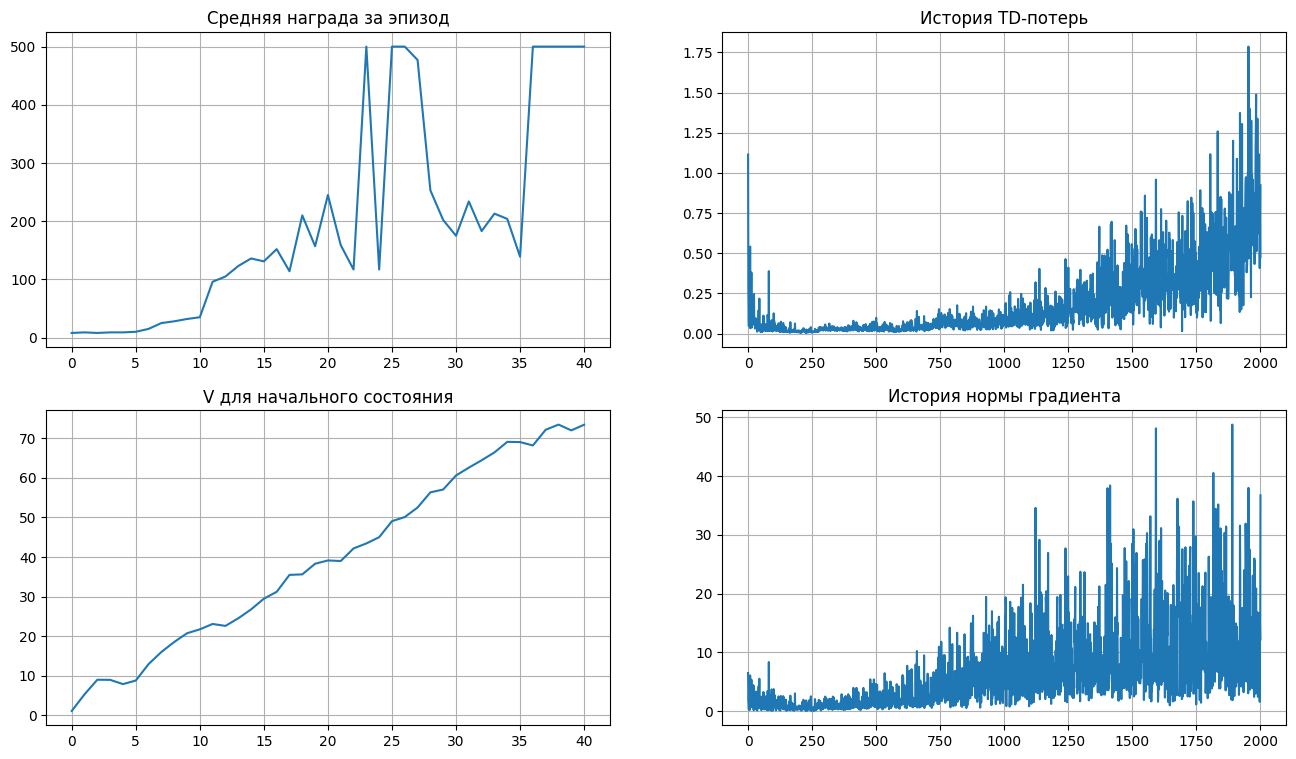

100%|██████████| 40001/40001 [17:57<00:00, 37.14it/s]


In [ ]:
state, _ = env.reset()
with trange(step, total_steps + 1) as progress_bar:
    for step in progress_bar:

        # играем
        _, state = play_and_record_weighted(state, agent, env, prioritized_exp_replay, timesteps_per_epoch)

        # обучаемся
        batch, idxs, weights = prioritized_exp_replay.sample(batch_size)
        obs_batch, act_batch, reward_batch, next_obs_batch, is_done_batch = zip(*batch)
        obs_batch = np.array(obs_batch)
        act_batch = np.array(act_batch)
        reward_batch = np.array(reward_batch)
        next_obs_batch = np.array(next_obs_batch)
        is_done_batch = np.array(is_done_batch)
        weights = np.array(weights)

        loss, td_errors = compute_td_loss_double_weighted(obs_batch, act_batch, reward_batch, next_obs_batch, is_done_batch,
                    agent, target_network, weights)

        loss.backward()
        grad_norm = nn.utils.clip_grad_norm_(agent.parameters(), max_grad_norm)
        opt.step()
        opt.zero_grad()
        # сэмплируем новый шум
        agent.q_network.reset_noise()

        for idx, td_error in zip(idxs, td_errors):
          prioritized_exp_replay.update(idx, td_error)

        if step % loss_freq == 0:
            td_loss_history.append(loss.data.cpu().item())
            grad_norm_history.append(grad_norm.cpu().item())

        if step % refresh_target_network_freq == 0:
            target_network.q_network.load_state_dict(agent.q_network.state_dict())

        if step % eval_freq == 0:
            mean_rw_history.append(evaluate_noisy(
                make_env(), agent, n_games=3, t_max=1000, seed=step)
            )
            initial_state_q_values = agent.get_qvalues(
                [make_env().reset(seed=step)[0]]
            )
            initial_state_v_history.append(np.max(initial_state_q_values))

            clear_output(True)

            plt.figure(figsize=[16, 9])

            plt.subplot(2, 2, 1)
            plt.title("Средняя награда за эпизод")
            plt.plot(mean_rw_history)
            plt.grid()

            assert not np.isnan(td_loss_history[-1])
            plt.subplot(2, 2, 2)
            plt.title("История TD-потерь")
            plt.plot(td_loss_history)
            plt.grid()

            plt.subplot(2, 2, 3)
            plt.title("V для начального состояния")
            plt.plot(initial_state_v_history)
            plt.grid()

            plt.subplot(2, 2, 4)
            plt.title("История нормы градиента")
            plt.plot(grad_norm_history)
            plt.grid()

            plt.show()

In [ ]:
final_score = evaluate_noisy(
  make_env(),
  agent, n_games=30, t_max=1000
)
print('итоговый результат:', final_score)

итоговый результат: 500.0


In [ ]:
import gymnasium as gym
import matplotlib.pyplot as plt

env = gym.make("CartPole-v1", render_mode="rgb_array")
obs, _ = env.reset()
frames = []

done = False
while not done:
    frames.append(env.render())
    qvalues = agent.get_qvalues([obs])
    action = qvalues.argmax(axis=-1)[0]
    obs, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated

env.close()

import imageio

imageio.mimsave('cartpole_agent_noizy.mp4', frames, fps=30, macro_block_size=None)

from IPython.display import Video
Video("cartpole_agent_noizy.mp4", embed=True)

общая награда за эпизод: 500.0


Text(0, 0.5, 'Агент')

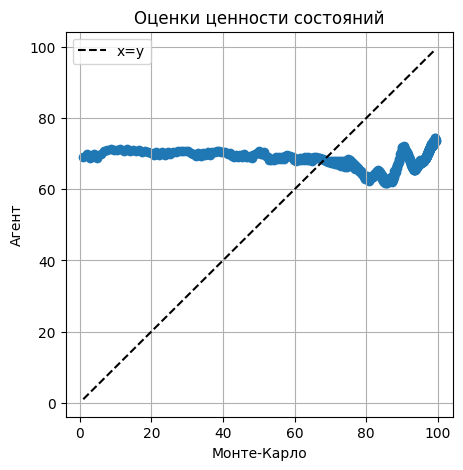

In [ ]:
eval_env = make_env()
record = play_and_log_episode(eval_env, agent)
print('общая награда за эпизод:', np.sum(record['rewards']))

fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(1, 1, 1)

# Вычисляем V-значения по Монте-Карло и по агенту
v_mc = get_discounted_returns(record['rewards'], 0.99)#np.array([np.sum(record['rewards'][i:] * (0.99 ** np.arange(len(record['rewards']) - i)))
#                 for i in range(len(record['rewards']))])
v_agent = np.max(record['qvalues'], axis=1)

ax.scatter(v_mc, v_agent)
ax.plot(sorted(v_mc), sorted(v_mc),
       'black', linestyle='--', label='x=y')

ax.grid()
ax.legend()
ax.set_title('Оценки ценности состояний')
ax.set_xlabel('Монте-Карло')
ax.set_ylabel('Агент')

### Distributional DQN C51

Distributional Noisy Dueling Double DQN с PER

Мы заменяем выход q-сети - вместо одного усредненного значения - набор значений(атомов), их значения зависят от задачи. Тогда q будет мат ожиданием. То есть мы под капотом начинаем вычислять вероятности для атомов.

In [ ]:
class DistributionalNoisyDuelingDQNHead(nn.Module):
    def __init__(self, input_dim, n_actions, n_atoms):
        super(DistributionalNoisyDuelingDQNHead, self).__init__()

        self.n_atoms = n_atoms
        self.n_actions = n_actions

        hidden_dim = 256
        self.advantage_stream = nn.Sequential(
            NoisyLinear(input_dim, hidden_dim),
            nn.ReLU(),
            NoisyLinear(hidden_dim, n_actions * n_atoms),
        )
        self.value_stream = nn.Sequential(
            NoisyLinear(input_dim, hidden_dim),
            nn.ReLU(),
            NoisyLinear(hidden_dim, n_atoms),
        )

    def forward(self, x):
        '''
        последний слой advantage_stream выдаёт вектор размерности [batch_size, n_actions * n_atoms],
          а нам нужно получить тензор размера [batch_size, n_actions, n_atoms]
        Это нужно, чтобы для каждого действия и каждого атома был отдельный логит.
        В Distributional RL (C51) мы хотим,
         чтобы для каждого действия сеть предсказывала распределение вероятностей по атомам (точкам на оси возможных возвратов)

        Пример:
          Допустим, у нас 3 атома: z = [-1, 0, 1]
          Сеть выдала логиты: [2.0, 0.0, -1.0]
          После softmax: [0.65, 0.24, 0.11]
          Это значит:
          Вероятность, что возврат ≈ -1: 65%
          Вероятность, что возврат ≈ 0: 24%
          Вероятность, что возврат ≈ 1: 11%
          Q(s, a) = 0.65 * (-1) + 0.24 * 0 + 0.11 * 1 = -0.54
        '''
        advantages_raw = self.advantage_stream(x)
        vvalues_raw = self.value_stream(x)

        batch_size = x.size(0)
        advantages = advantages_raw.view(batch_size, self.n_actions, self.n_atoms)
        vvalues = vvalues_raw.view(batch_size, 1, self.n_atoms)

        mean_advantages = advantages.mean(dim=1, keepdim=True)
        centered_advantages = advantages - mean_advantages
        # "сырые" значения (логиты) для каждого атома в этом действии.
        q_atoms = vvalues + centered_advantages # [batch_size, n_actions, n_atoms]
        # вероятность, что Q будет равен z_atom. то есть мы фиксируем набор атомов(награды), а затем получаем вероятность фиксированной награды
        probs = torch.softmax(q_atoms, dim=2) # dim=2 ось атомов
        return probs  # [batch, n_actions, n_atoms]

    def reset_noise(self):
        for m in self.modules():
            if isinstance(m, NoisyLinear):
                m.reset_noise()

In [ ]:
class DistributionalNoisyDuelingDQN(nn.Module):
    def __init__(self, state_shape, n_actions, n_atoms):
        super(DistributionalNoisyDuelingDQN, self).__init__()
        state_dim = state_shape[0]
        hidden_dim = 192
        self.feature_extractor = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )
        self.dueling_head = DistributionalNoisyDuelingDQNHead(hidden_dim, n_actions, n_atoms)

    def forward(self, x):
        features = self.feature_extractor(x)
        probs = self.dueling_head(features)
        return probs

    def reset_noise(self):
        self.dueling_head.reset_noise()

In [ ]:
class DistributionalNoisyDuelingDQNAgent(nn.Module):
    def __init__(self, state_shape, n_actions, n_atoms, v_min, v_max):
        super(DistributionalNoisyDuelingDQNAgent, self).__init__()
        self.state_shape = state_shape
        self.n_actions = n_actions
        self.n_atoms = n_atoms
        self.v_min = v_min
        self.v_max = v_max
        assert len(state_shape) == 1
        self.q_network = DistributionalNoisyDuelingDQN(state_shape, n_actions, n_atoms)

    def forward(self, state_t):
        probs = self.q_network(state_t)
        return probs # [batch, n_actions, n_atoms]

    def get_qvalues(self, states):
        states = torch.tensor(states, device=device, dtype=torch.float32)
        with torch.no_grad():
          probs = self.forward(states)
          # Если v_min=0, v_max=500, n_atoms=5, то [0, 125, 250, 375, 500]
          atoms_value = torch.linspace(self.v_min, self.v_max, self.n_atoms).to(probs.device)
          # мат ожидание q-value
          qvalues = (probs * atoms_value).sum(dim=2)
        return qvalues.data.cpu().numpy()

    def sample_actions(self, qvalues_batches):
        return qvalues_batches.argmax(axis=-1)

#### Теория

Самая сложная часть это как проводить обучение на атомах. Мы получаем таргет по значениям атомов, а не по вероятностям. В противном случае терялся бы смысл Distributional RL, потому что мы бы снова учили среднее. Это единственный способ корректно обучать сеть предсказывать распределение по фиксированному набору атомов.

После шага среды значения атомов не совпадают с исходными. Если бы мы просто взяли вероятности из target-сети, они бы относились к старым атомам (например, 0, 1, 2, 3, 4), а не к новым значениям (например, 1.0, 1.9, 2.8, 3.7, 4.6). Поэтому их необходимо перевести. Для этого переносим target-распределение после шага среды на support, размазывая вероятности между ближайшими атомами.

Loss (кросс-энтропия) сравнивает предсказанное распределение и target-распределение только для выбранного действия.
Веса сети обновляются так, чтобы предсказанное распределение для этого действия стало ближе к target-распределению.

Пример:

**Исходные данные**

- **Support (атомы):**  
  `z = [0, 1, 2, 3, 4]`  
  (v_min=0, v_max=4, n_atoms=5, delta_z=1)

- **Вероятности по атомам для двух действий в одном состоянии:**  
  - Для действия "влево":  
    `probs_left = [0.1, 0.2, 0.4, 0.2, 0.1]`
  - Для действия "вправо":  
    `probs_right = [0.0, 0.0, 0.2, 0.3, 0.5]`

---

**1. Агент выбирает действие**

- Считаем Q для каждого действия (мат. ожидание):
  - Q_left = 0.1×0 + 0.2×1 + 0.4×2 + 0.2×3 + 0.1×4 = 0 + 0.2 + 0.8 + 0.6 + 0.4 = **2.0**
  - Q_right = 0.0×0 + 0.0×1 + 0.2×2 + 0.3×3 + 0.5×4 = 0 + 0 + 0.4 + 0.9 + 2.0 = **3.3**
- Агент выбирает "вправо" (Q_right больше).

---


**2. Bellman backup (шаг среды)**

- Пусть reward = 1, gamma = 0.9, is_not_done = 1.
- Для каждого атома z_j из выбранного действия ("вправо"):
  - Tz_j = r + gamma * z_j

| z_j | Tz_j = 1 + 0.9*z_j |
|-----|--------------------|
| 0   | 1 + 0.9×0 = 1.0    |
| 1   | 1 + 0.9×1 = 1.9    |
| 2   | 1 + 0.9×2 = 2.8    |
| 3   | 1 + 0.9×3 = 3.7    |
| 4   | 1 + 0.9×4 = 4.6    | (clamp до 4.0, если v_max=4)

- После clamp:  
  Tz = [1.0, 1.9, 2.8, 3.7, 4.0]

---

**3. Bellman projection: размазываем вероятности**

Теперь для каждого Tz_j определяем, между какими атомами он оказался, и делим вероятность probs_right[j] между ними:

| Tz_j | l | u | b         | probs_right[j] | Вклад в l | Вклад в u |
|------|---|---|-----------|---------------|-----------|-----------|
| 1.0  | 1 | 1 | 1.0       | 0.0           | 0.0       | 0.0       |
| 1.9  | 1 | 2 | 1.9       | 0.0           | 0.0       | 0.0       |
| 2.8  | 2 | 3 | 2.8       | 0.2           | 0.2×(3-2.8)=0.04 | 0.2×(2.8-2)=0.16 |
| 3.7  | 3 | 4 | 3.7       | 0.3           | 0.3×(4-3.7)=0.09 | 0.3×(3.7-3)=0.21 |
| 4.0  | 4 | 4 | 4.0       | 0.5           | 0.5       | 0         |

**Суммируем вклады по атомам:**

- z_0: 0
- z_1: 0
- z_2: 0.04
- z_3: 0.16 + 0.09 = 0.25
- z_4: 0.21 + 0.5 = 0.71

**Итоговое target-распределение по атомам для следующего состояния:**
- `[0, 0, 0.04, 0.25, 0.71]`

После перевода видно, что для действия ("вправо") сеть предсказывала распределение по атомам: [0.0, 0.0, 0.2, 0.3, 0.5], а target-распределение ([0, 0, 0.04, 0.25, 0.71]) — это то, чему сеть должна стремиться

---

**4. Что мы делаем на практике?**

- Для каждого перехода и каждого атома target-распределения:
  - Считаем Tz_j = r + gamma * z_j
  - Находим, между какими атомами support оказался Tz_j
  - Размазываем вероятность probs[j] между этими атомами пропорционально расстоянию

---

**5. Если эпизод завершён (is_not_done=0):**

- Tz_j = r для всех j, то есть все Tz_j совпадают и вся вероятность идёт в ближайший к r атом.

---

**Кратко**

- **Support** — общий для всех действий.
- **Вероятности** — свои для каждого действия.
- **Bellman projection** — переносим target-распределение после шага среды на support, размазывая вероятности между ближайшими атомами.
- **В итоге**: для каждого действия и состояния сеть учится предсказывать распределение возвратов, а не только среднее.


##### Кросс-энтропия

**Кросс-энтропия** — это мера "расстояния" между двумя вероятностными распределениями. Она широко используется в машинном обучении, особенно в задачах классификации и в Distributional RL.

---

**Интуитивно:**
- Кросс-энтропия показывает, **насколько плохо одно распределение (Q)** приближает другое (P).
- Чем больше кросс-энтропия, тем "дальше" друг от друга распределения.
- Если они совпадают идеально, кросс-энтропия = 0.

---

**Формула:**

Для двух распределений \( P \) (target, истинное) и \( Q \) (предсказанное сетью) по n классам (или атомам):

\[
\text{CrossEntropy}(P, Q) = -\sum_{i=1}^n P_i \log Q_i
\]

- \( P_i \) — вероятность i-го класса (или атома) в target-распределении.
- \( Q_i \) — вероятность i-го класса (или атома) в предсказанном распределении.

---

**В задачах RL (C51):**

- \( P \) — target-распределение по атомам (после Bellman projection).
- \( Q \) — предсказанное сетью распределение по атомам для выбранного действия.

---

**Пример:**

Допустим, у нас 3 атома (или класса):

- Target (P): [0.1, 0.7, 0.2]
- Predicted (Q): [0.2, 0.5, 0.3]

Кросс-энтропия:
\[
- (0.1 \cdot \log 0.2 + 0.7 \cdot \log 0.5 + 0.2 \cdot \log 0.3)
\]

---

**Почему именно так?**

- Если \( Q_i \) близко к нулю там, где \( P_i \) велико, loss будет очень большим (наказание за "уверенность в ошибке").
- Если \( Q_i \) совпадает с \( P_i \) для всех i, loss минимален (идеальное совпадение).

---

**В машинном обучении:**

- В задачах классификации кросс-энтропия — это loss-функция для softmax-выхода.
- В Distributional RL — это loss между target-распределением и предсказанным распределением по атомам.

---

**Кратко**

- **Кросс-энтропия** — это мера того, насколько предсказанное распределение близко к target-распределению.
- Чем меньше кросс-энтропия — тем лучше сеть "угадывает" вероятности.

####

In [ ]:
def compute_td_loss_distributional_double_weighted(
    states,
    actions,
    rewards,
    next_states,
    is_done,
    agent: nn.Module,
    target_network: nn.Module,
    weights,
    v_min,
    v_max,
    n_atoms,
    gamma: float = 0.99,
    check_shapes=False,
):
    batch_size = len(states)

    states = torch.tensor(states, device=device, dtype=torch.float32)                      # shape: [batch_size, *state_shape]
    actions = torch.tensor(actions, device=device, dtype=torch.int64)                      # shape: [batch_size]
    rewards = torch.tensor(rewards, device=device, dtype=torch.float32)                    # shape: [batch_size]
    next_states = torch.tensor(next_states, device=device, dtype=torch.float)              # shape: [batch_size, *state_shape]
    is_done = torch.tensor(is_done.astype('float32'), device=device, dtype=torch.float32)  # shape: [batch_size]
    is_not_done = 1 - is_done

    predicted_probs = agent(states)
    predicted_probs_for_actions = predicted_probs[range(batch_size), actions, :]

    next_qvalues = target_network.get_qvalues(next_states)
    next_actions = next_qvalues.argmax(axis=1)

    with torch.no_grad():
      next_predicted_probs = target_network(next_states)
    next_predicted_probs_for_actions = next_predicted_probs[range(batch_size), next_actions, :]

    # ===> Bellman projection
    """
    В Distributional RL (C51) мы хотим, чтобы сеть предсказывала распределение возможных суммарных наград (возвратов) для каждого действия.
    У каждого действия — свой набор вероятностей по атомам, но support (значения атомов [0, 125, 250, 375, 500]) общий.
    Для каждого действия сеть предсказывает своё распределение вероятностей по этим атомам.

    Когда мы делаем шаг среды, мы хотим узнать, каким станет распределение возвратов для нового состояния.
    Для этого мы берём target-распределение (например, для лучшего действия в next_state) — это вероятности по атомам на support.
    Каждый атом этого распределения "сдвигается" по формуле Беллмана:
    Tz_j = r + gamma * z_j (или r, если done)
    После сдвига значения Tz_j могут не совпадать с исходным support, поэтому мы "размазываем" вероятность между ближайшими атомами support (Bellman projection).

    """
    support = torch.linspace(v_min, v_max, n_atoms).to(device)  # [n_atoms]
    # Расстояние между соседними атомами (шаг дискретизации).
    delta_z = (v_max - v_min) / (n_atoms - 1)
    target_qvalues_for_atoms = rewards.unsqueeze(1) + gamma * is_not_done.unsqueeze(1) * support.unsqueeze(0)  # [batch, n_atoms]
    target_qvalues_for_atoms = target_qvalues_for_atoms.clamp(v_min, v_max)
    b = (target_qvalues_for_atoms - v_min) / delta_z
    left = b.floor().long()
    right = b.ceil().long()

    target_probs_for_actions = torch.zeros_like(next_predicted_probs_for_actions)
    for i in range(n_atoms):
        eq_mask = (right[:, i] == left[:, i])
        target_probs_for_actions[range(batch_size), left[:, i]] += next_predicted_probs_for_actions[:, i] * (right[:, i].float() - b[:, i] + eq_mask.float())
        target_probs_for_actions[range(batch_size), right[:, i]] += next_predicted_probs_for_actions[:, i] * (b[:, i] - left[:, i].float())
    # <=== Bellman projection

    # логарифм вероятности по атомам, предсказанные сетью для выбранного действия
    log_p = torch.log(predicted_probs_for_actions + 1e-8)
    # Кросс-энтропия — стандартная мера "расстояния" между двумя вероятностными распределениями.
    elementwise_loss = -(target_probs_for_actions * log_p).sum(dim=1)
    if weights is not None:
        weights = torch.tensor(weights, device=elementwise_loss.device, dtype=elementwise_loss.dtype)
        loss = torch.mean(elementwise_loss * weights)
    else:
        loss = torch.mean(elementwise_loss)
    # TD-ошибка для PER (можно взять разницу в ожиданиях)
    td_errors = (predicted_probs_for_actions * support).sum(dim=1) - (target_probs_for_actions * support).sum(dim=1)

    return loss, td_errors.detach().cpu().numpy()

In [ ]:
timesteps_per_epoch = 10
batch_size = 256
total_steps = 4 * 10**4
decay_steps = 1 * 10**4

init_epsilon = 1
final_epsilon = 0.1

loss_freq = 20
refresh_target_network_freq = 300
eval_freq = 1000

lr=5e-4

max_grad_norm = 10

REPLAY_BUFFER_SIZE = 10**5

n_atoms=51
v_min=0
v_max=500

In [ ]:
env = make_env()
env.reset()
state_shape, n_actions = env.observation_space.shape, env.action_space.n

# Инициализируем агента и целевую сеть
agent = DistributionalNoisyDuelingDQNAgent(state_shape, n_actions, n_atoms, v_min, v_max).to(device)
target_network = DistributionalNoisyDuelingDQNAgent(state_shape, n_actions, n_atoms, v_min, v_max).to(device)
target_network.q_network.load_state_dict(agent.q_network.state_dict())

opt = torch.optim.Adam(agent.parameters(), lr=lr)
prioritized_exp_replay = PrioritizedReplayBuffer(REPLAY_BUFFER_SIZE)

In [ ]:
for i in range(300):
    play_and_record_weighted(state, agent, env, prioritized_exp_replay, n_steps=10**2)

In [ ]:
mean_rw_history = []
td_loss_history = []
grad_norm_history = []
initial_state_v_history = []
step = 0

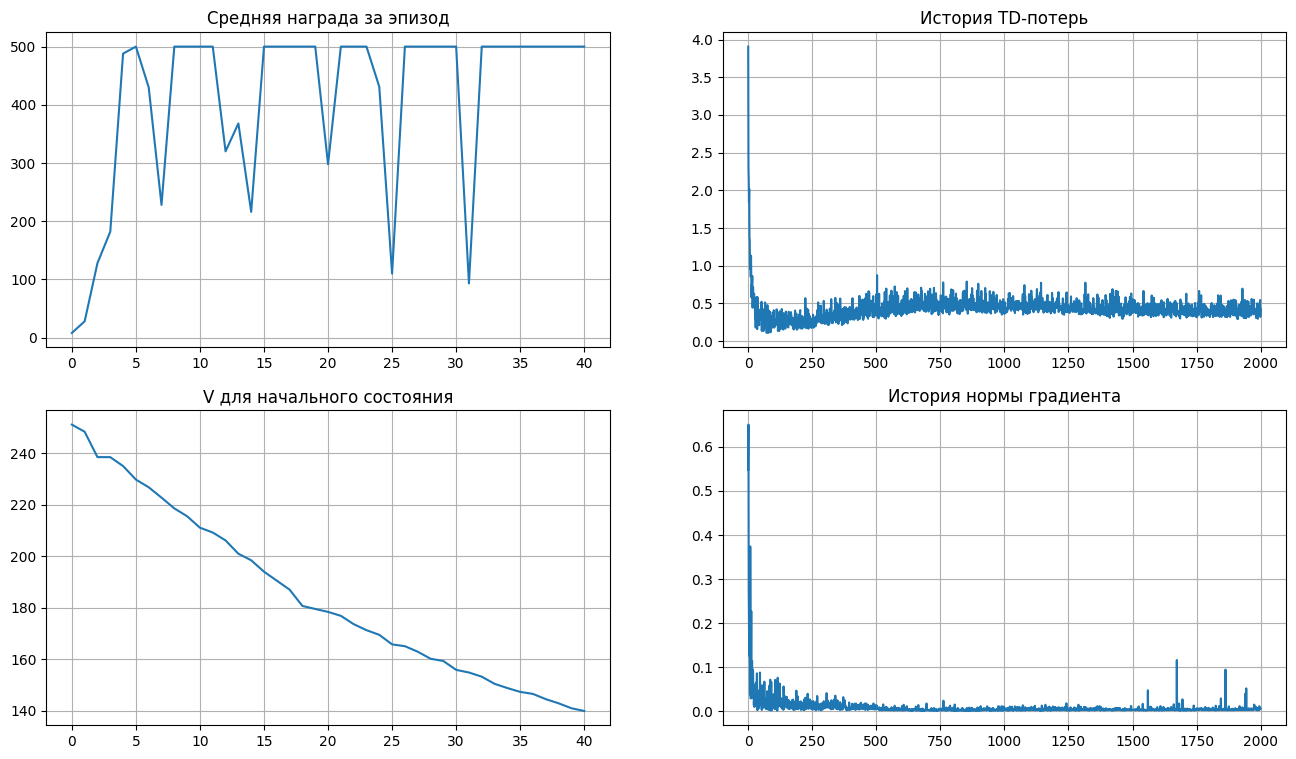

100%|██████████| 40001/40001 [49:35<00:00, 13.44it/s]


In [ ]:
state, _ = env.reset()
with trange(step, total_steps + 1) as progress_bar:
    for step in progress_bar:

        # играем
        _, state = play_and_record_weighted(state, agent, env, prioritized_exp_replay, timesteps_per_epoch)

        # обучаемся
        batch, idxs, weights = prioritized_exp_replay.sample(batch_size)
        obs_batch, act_batch, reward_batch, next_obs_batch, is_done_batch = zip(*batch)
        obs_batch = np.array(obs_batch)
        act_batch = np.array(act_batch)
        reward_batch = np.array(reward_batch)
        next_obs_batch = np.array(next_obs_batch)
        is_done_batch = np.array(is_done_batch)
        weights = np.array(weights)

        loss, td_errors = compute_td_loss_distributional_double_weighted(obs_batch, act_batch, reward_batch, next_obs_batch, is_done_batch,
                    agent, target_network, weights, v_min, v_max, n_atoms)

        loss.backward()
        grad_norm = nn.utils.clip_grad_norm_(agent.parameters(), max_grad_norm)
        opt.step()
        opt.zero_grad()
        # сэмплируем новый шум
        agent.q_network.reset_noise()

        for idx, td_error in zip(idxs, td_errors):
          prioritized_exp_replay.update(idx, td_error)

        if step % loss_freq == 0:
            td_loss_history.append(loss.data.cpu().item())
            grad_norm_history.append(grad_norm.cpu().item())

        if step % refresh_target_network_freq == 0:
            target_network.q_network.load_state_dict(agent.q_network.state_dict())

        if step % eval_freq == 0:
            mean_rw_history.append(evaluate_noisy(
                make_env(), agent, n_games=3, t_max=1000, seed=step)
            )
            initial_state_q_values = agent.get_qvalues(
                [make_env().reset(seed=step)[0]]
            )
            initial_state_v_history.append(np.max(initial_state_q_values))

            clear_output(True)

            plt.figure(figsize=[16, 9])

            plt.subplot(2, 2, 1)
            plt.title("Средняя награда за эпизод")
            plt.plot(mean_rw_history)
            plt.grid()

            assert not np.isnan(td_loss_history[-1])
            plt.subplot(2, 2, 2)
            plt.title("История TD-потерь")
            plt.plot(td_loss_history)
            plt.grid()

            plt.subplot(2, 2, 3)
            plt.title("V для начального состояния")
            plt.plot(initial_state_v_history)
            plt.grid()

            plt.subplot(2, 2, 4)
            plt.title("История нормы градиента")
            plt.plot(grad_norm_history)
            plt.grid()

            plt.show()

In [ ]:
final_score = evaluate_noisy(
  make_env(),
  agent, n_games=30, t_max=1000
)
print('итоговый результат:', final_score)

итоговый результат: 500.0


In [ ]:
import gymnasium as gym
import matplotlib.pyplot as plt

env = gym.make("CartPole-v1", render_mode="rgb_array")
obs, _ = env.reset()
frames = []

done = False
while not done:
    frames.append(env.render())
    qvalues = agent.get_qvalues([obs])
    action = qvalues.argmax(axis=-1)[0]
    obs, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated

env.close()

import imageio

imageio.mimsave('cartpole_agent_c51.mp4', frames, fps=30, macro_block_size=None)

from IPython.display import Video
Video("cartpole_agent_c51.mp4", embed=True)

общая награда за эпизод: 500.0


Text(0, 0.5, 'Агент')

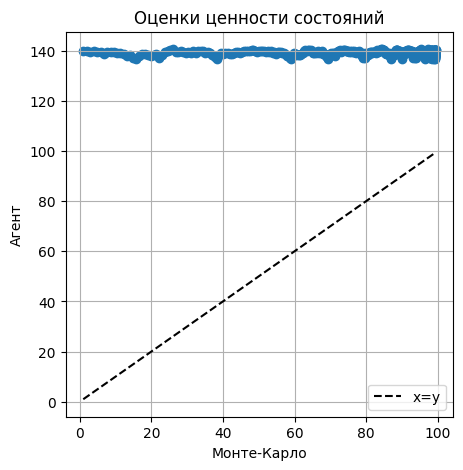

In [ ]:
eval_env = make_env()
record = play_and_log_episode(eval_env, agent)
print('общая награда за эпизод:', np.sum(record['rewards']))

fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(1, 1, 1)

# Вычисляем V-значения по Монте-Карло и по агенту
v_mc = get_discounted_returns(record['rewards'], 0.99)#np.array([np.sum(record['rewards'][i:] * (0.99 ** np.arange(len(record['rewards']) - i)))
#                 for i in range(len(record['rewards']))])
v_agent = np.max(record['qvalues'], axis=1)

ax.scatter(v_mc, v_agent)
ax.plot(sorted(v_mc), sorted(v_mc),
       'black', linestyle='--', label='x=y')

ax.grid()
ax.legend()
ax.set_title('Оценки ценности состояний')
ax.set_xlabel('Монте-Карло')
ax.set_ylabel('Агент')

### n-step

С добавлением этой модификации получаем Rainbow DQN

In [ ]:
from collections import deque

def play_and_record_rainbow(initial_state, agent, env, prioritized_exp_replay, n_steps=1, n=3, gamma=0.99):
    """
    Играет в игру ровно n_steps шагов, записывая каждый n-step кортеж (s,a,R,s', done) в буфер воспроизведения.
    R = r_0 + gamma*r_1 + ... + gamma^{n-1}*r_{n-1}
    """
    s = initial_state
    sum_rewards = 0

    state_queue = deque()
    action_queue = deque()
    reward_queue = deque()
    done_queue = deque()

    for _ in range(n_steps):
        qvalues = agent.get_qvalues([s])
        action = agent.sample_actions(qvalues)[0]

        next_s, r, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        state_queue.append(s)
        action_queue.append(action)
        reward_queue.append(r)
        done_queue.append(done)

        # Если накопили n шагов или эпизод завершён — добавляем n-step переход
        if len(reward_queue) == n or done:
            R = 0
            for idx in range(len(reward_queue)):
                R += (gamma ** idx) * reward_queue[idx]
            # Получаем максимальный приоритет из буфера
            if prioritized_exp_replay.tree.n_entries > 0:
                max_prio = np.max(prioritized_exp_replay.tree.tree[-prioritized_exp_replay.capacity:])
            else:
                max_prio = 1.0
            prioritized_exp_replay.add(
                max_prio,
                (state_queue[0], action_queue[0], R, next_s, done)
            )
            state_queue.popleft()
            action_queue.popleft()
            reward_queue.popleft()
            done_queue.popleft()

        sum_rewards += r
        if done:
            s, _ = env.reset()
            state_queue.clear()
            action_queue.clear()
            reward_queue.clear()
            done_queue.clear()
        else:
            s = next_s

    return sum_rewards, s

In [ ]:
def compute_td_loss_rainbow(
    states,
    actions,
    rewards,
    next_states,
    is_done,
    agent: nn.Module,
    target_network: nn.Module,
    weights,
    v_min,
    v_max,
    n_atoms,
    n,
    gamma: float = 0.99,
):
    batch_size = len(states)

    states = torch.tensor(states, device=device, dtype=torch.float32)                      # shape: [batch_size, *state_shape]
    actions = torch.tensor(actions, device=device, dtype=torch.int64)                      # shape: [batch_size]
    rewards = torch.tensor(rewards, device=device, dtype=torch.float32)                    # shape: [batch_size]
    next_states = torch.tensor(next_states, device=device, dtype=torch.float)              # shape: [batch_size, *state_shape]
    is_done = torch.tensor(is_done.astype('float32'), device=device, dtype=torch.float32)  # shape: [batch_size]
    is_not_done = 1 - is_done

    predicted_probs = agent(states)
    predicted_probs_for_actions = predicted_probs[range(batch_size), actions, :]

    next_qvalues = target_network.get_qvalues(next_states)
    next_actions = next_qvalues.argmax(axis=1)

    with torch.no_grad():
      next_predicted_probs = target_network(next_states)
    next_predicted_probs_for_actions = next_predicted_probs[range(batch_size), next_actions, :]

    # ===> Bellman projection
    """
    В Distributional RL (C51) мы хотим, чтобы сеть предсказывала распределение возможных суммарных наград (возвратов) для каждого действия.
    У каждого действия — свой набор вероятностей по атомам, но support (значения атомов [0, 125, 250, 375, 500]) общий.
    Для каждого действия сеть предсказывает своё распределение вероятностей по этим атомам.

    Когда мы делаем шаг среды, мы хотим узнать, каким станет распределение возвратов для нового состояния.
    Для этого мы берём target-распределение (например, для лучшего действия в next_state) — это вероятности по атомам на support.
    Каждый атом этого распределения "сдвигается" по формуле Беллмана:
    Tz_j = r + gamma * z_j (или r, если done)
    После сдвига значения Tz_j могут не совпадать с исходным support, поэтому мы "размазываем" вероятность между ближайшими атомами support (Bellman projection).

    """
    support = torch.linspace(v_min, v_max, n_atoms).to(device)  # [n_atoms]
    # Расстояние между соседними атомами (шаг дискретизации).
    delta_z = (v_max - v_min) / (n_atoms - 1)
    target_qvalues_for_atoms = rewards.unsqueeze(1) + gamma**n * is_not_done.unsqueeze(1) * support.unsqueeze(0)  # [batch, n_atoms]
    target_qvalues_for_atoms = target_qvalues_for_atoms.clamp(v_min, v_max)
    b = (target_qvalues_for_atoms - v_min) / delta_z
    left = b.floor().long()
    right = b.ceil().long()

    target_probs_for_actions = torch.zeros_like(next_predicted_probs_for_actions)
    for i in range(n_atoms):
        eq_mask = (right[:, i] == left[:, i])
        target_probs_for_actions[range(batch_size), left[:, i]] += next_predicted_probs_for_actions[:, i] * (right[:, i].float() - b[:, i] + eq_mask.float())
        target_probs_for_actions[range(batch_size), right[:, i]] += next_predicted_probs_for_actions[:, i] * (b[:, i] - left[:, i].float())
    # <=== Bellman projection

    # логарифм вероятности по атомам, предсказанные сетью для выбранного действия
    log_p = torch.log(predicted_probs_for_actions + 1e-8)
    # Кросс-энтропия — стандартная мера "расстояния" между двумя вероятностными распределениями.
    elementwise_loss = -(target_probs_for_actions * log_p).sum(dim=1)
    if weights is not None:
        weights = torch.tensor(weights, device=elementwise_loss.device, dtype=elementwise_loss.dtype)
        loss = torch.mean(elementwise_loss * weights)
    else:
        loss = torch.mean(elementwise_loss)
    # TD-ошибка для PER (можно взять разницу в ожиданиях)
    td_errors = (predicted_probs_for_actions * support).sum(dim=1) - (target_probs_for_actions * support).sum(dim=1)

    return loss, td_errors.detach().cpu().numpy()

In [ ]:
timesteps_per_epoch = 10
batch_size = 256
total_steps = 4 * 10**4
decay_steps = 1 * 10**4

init_epsilon = 1
final_epsilon = 0.1

loss_freq = 20
refresh_target_network_freq = 300
eval_freq = 1000

lr=5e-4

max_grad_norm = 10

REPLAY_BUFFER_SIZE = 10**5

n_atoms=51
v_min=0
v_max=500

n=5

In [ ]:
env = make_env()
env.reset()
state_shape, n_actions = env.observation_space.shape, env.action_space.n

# Инициализируем агента и целевую сеть
agent = DistributionalNoisyDuelingDQNAgent(state_shape, n_actions, n_atoms, v_min, v_max).to(device)
target_network = DistributionalNoisyDuelingDQNAgent(state_shape, n_actions, n_atoms, v_min, v_max).to(device)
target_network.q_network.load_state_dict(agent.q_network.state_dict())

opt = torch.optim.Adam(agent.parameters(), lr=lr)
prioritized_exp_replay = PrioritizedReplayBuffer(REPLAY_BUFFER_SIZE)

In [ ]:
for i in range(300):
    play_and_record_weighted(state, agent, env, prioritized_exp_replay, n_steps=10**2)

In [ ]:
mean_rw_history = []
td_loss_history = []
grad_norm_history = []
initial_state_v_history = []
step = 0

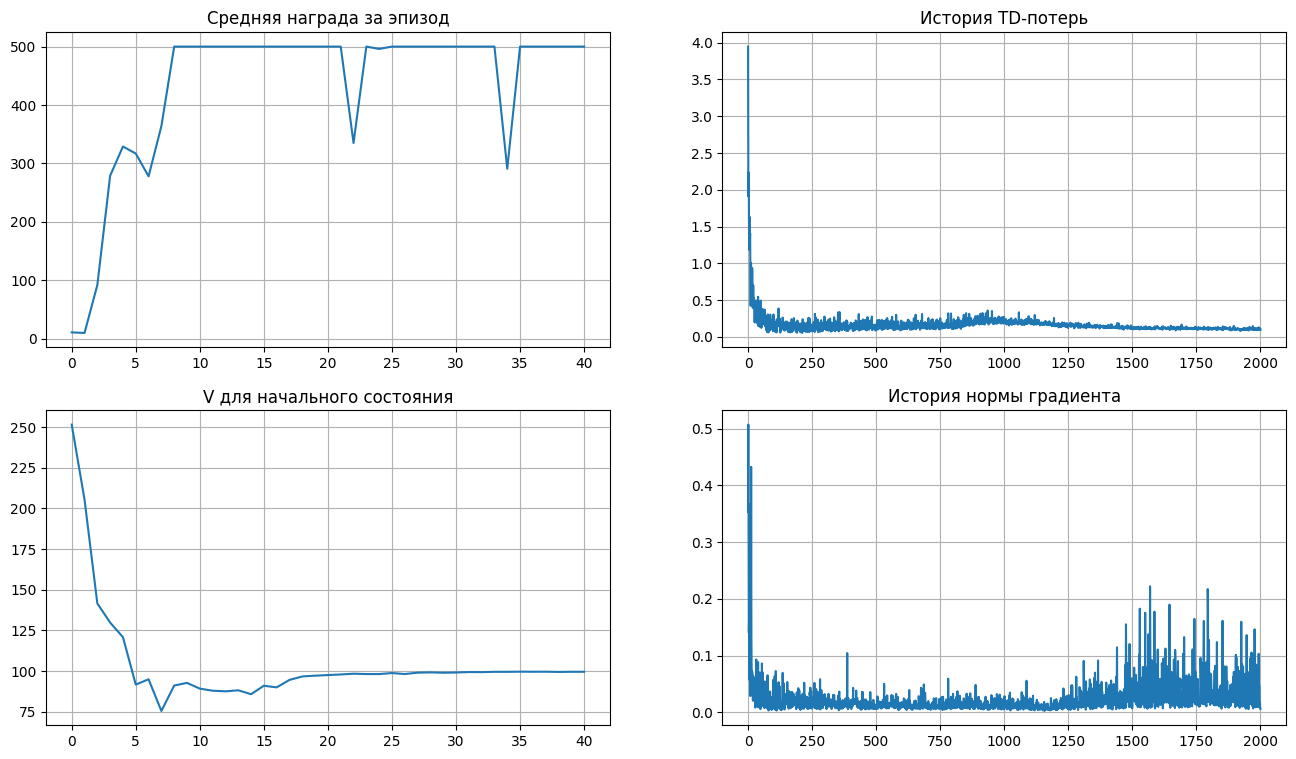

100%|██████████| 40001/40001 [49:06<00:00, 13.58it/s]


In [ ]:
state, _ = env.reset()
with trange(step, total_steps + 1) as progress_bar:
    for step in progress_bar:

        # играем
        _, state = play_and_record_rainbow(state, agent, env, prioritized_exp_replay, timesteps_per_epoch, n)

        # обучаемся
        batch, idxs, weights = prioritized_exp_replay.sample(batch_size)
        obs_batch, act_batch, reward_batch, next_obs_batch, is_done_batch = zip(*batch)
        obs_batch = np.array(obs_batch)
        act_batch = np.array(act_batch)
        reward_batch = np.array(reward_batch)
        next_obs_batch = np.array(next_obs_batch)
        is_done_batch = np.array(is_done_batch)
        weights = np.array(weights)

        loss, td_errors = compute_td_loss_rainbow(obs_batch, act_batch, reward_batch, next_obs_batch, is_done_batch,
                    agent, target_network, weights, v_min, v_max, n_atoms, n)

        loss.backward()
        grad_norm = nn.utils.clip_grad_norm_(agent.parameters(), max_grad_norm)
        opt.step()
        opt.zero_grad()
        # сэмплируем новый шум
        agent.q_network.reset_noise()

        for idx, td_error in zip(idxs, td_errors):
          prioritized_exp_replay.update(idx, td_error)

        if step % loss_freq == 0:
            td_loss_history.append(loss.data.cpu().item())
            grad_norm_history.append(grad_norm.cpu().item())

        if step % refresh_target_network_freq == 0:
            target_network.q_network.load_state_dict(agent.q_network.state_dict())

        if step % eval_freq == 0:
            mean_rw_history.append(evaluate_noisy(
                make_env(), agent, n_games=3, t_max=1000, seed=step)
            )
            initial_state_q_values = agent.get_qvalues(
                [make_env().reset(seed=step)[0]]
            )
            initial_state_v_history.append(np.max(initial_state_q_values))

            clear_output(True)

            plt.figure(figsize=[16, 9])

            plt.subplot(2, 2, 1)
            plt.title("Средняя награда за эпизод")
            plt.plot(mean_rw_history)
            plt.grid()

            assert not np.isnan(td_loss_history[-1])
            plt.subplot(2, 2, 2)
            plt.title("История TD-потерь")
            plt.plot(td_loss_history)
            plt.grid()

            plt.subplot(2, 2, 3)
            plt.title("V для начального состояния")
            plt.plot(initial_state_v_history)
            plt.grid()

            plt.subplot(2, 2, 4)
            plt.title("История нормы градиента")
            plt.plot(grad_norm_history)
            plt.grid()

            plt.show()

In [ ]:
final_score = evaluate_noisy(
  make_env(),
  agent, n_games=30, t_max=1000
)
print('итоговый результат:', final_score)

итоговый результат: 500.0


In [ ]:
import gymnasium as gym
import matplotlib.pyplot as plt

env = gym.make("CartPole-v1", render_mode="rgb_array")
obs, _ = env.reset()
frames = []

done = False
while not done:
    frames.append(env.render())
    qvalues = agent.get_qvalues([obs])
    action = qvalues.argmax(axis=-1)[0]
    obs, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated

env.close()

import imageio

imageio.mimsave('cartpole_agent_rainbow.mp4', frames, fps=30, macro_block_size=None)

from IPython.display import Video
Video("cartpole_agent_rainbow.mp4", embed=True)

общая награда за эпизод: 500.0


Text(0, 0.5, 'Агент')

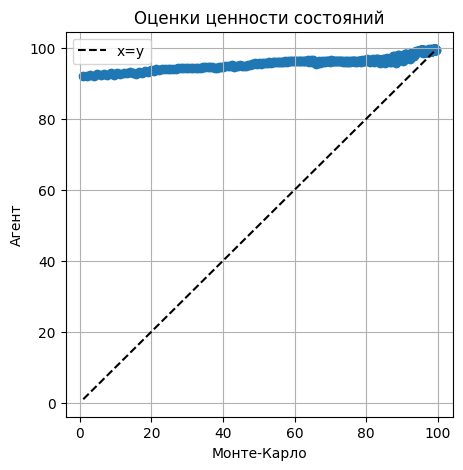

In [ ]:
eval_env = make_env()
record = play_and_log_episode(eval_env, agent)
print('общая награда за эпизод:', np.sum(record['rewards']))

fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(1, 1, 1)

# Вычисляем V-значения по Монте-Карло и по агенту
v_mc = get_discounted_returns(record['rewards'], 0.99)#np.array([np.sum(record['rewards'][i:] * (0.99 ** np.arange(len(record['rewards']) - i)))
#                 for i in range(len(record['rewards']))])
v_agent = np.max(record['qvalues'], axis=1)

ax.scatter(v_mc, v_agent)
ax.plot(sorted(v_mc), sorted(v_mc),
       'black', linestyle='--', label='x=y')

ax.grid()
ax.legend()
ax.set_title('Оценки ценности состояний')
ax.set_xlabel('Монте-Карло')
ax.set_ylabel('Агент')